# 🌍 Customer Intelligence System — Country Data
## End-to-End ML Pipeline: Classification · Ensemble Learning · Clustering

**Dataset:** HELP International — 167 countries, 9 socio-economic & health features  
**Goal:** Identify countries most in need of aid using unsupervised clustering, plus supervised classification & ensemble models for predictive intelligence.

---


## 1. 📦 Imports & Setup

In [1]:

import warnings
warnings.filterwarnings('ignore')

# Core
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from mpl_toolkits.mplot3d import Axes3D

# Preprocessing & Feature Engineering
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA

# Model Selection
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, StratifiedKFold

# Classifiers
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC

# Ensemble Models
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, VotingClassifier, BaggingClassifier
from xgboost import XGBClassifier

# Clustering
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.metrics import silhouette_score, davies_bouldin_score

# Metrics
from sklearn.metrics import (classification_report, confusion_matrix,
                              accuracy_score, roc_auc_score, roc_curve,
                              ConfusionMatrixDisplay)

# Scipy
from scipy.cluster.hierarchy import dendrogram, linkage
from scipy.stats import f_oneway

# Suppress XGBoost warnings
import os
os.environ['PYTHONWARNINGS'] = 'ignore'

# Seaborn style
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.dpi'] = 120
plt.rcParams['figure.figsize'] = (10, 6)

print("✅ All libraries imported successfully!")


✅ All libraries imported successfully!


## 2. 📂 Load & Inspect Data

In [2]:

# ── Load datasets ─────────────────────────────────────────────────────────
df_dict = pd.read_csv('data-dictionary.csv')
df = pd.read_csv('Country-data.csv')

print("📖 DATA DICTIONARY")
print("=" * 70)
display(df_dict)

print(f"\n📊 DATASET SHAPE: {df.shape[0]} rows × {df.shape[1]} columns")
print("\n🔍 FIRST 5 ROWS:")
display(df.head())

print("\n📈 STATISTICAL SUMMARY:")
display(df.describe().T.style.background_gradient(cmap='Blues'))


📖 DATA DICTIONARY


,Column Name,Description
0,country,Name of the country
1,child_mort,Death of children under 5 years of age per 100...
2,exports,Exports of goods and services per capita. Give...
3,health,Total health spending per capita. Given as %ag...
4,imports,Imports of goods and services per capita. Give...
5,Income,Net income per person
6,Inflation,The measurement of the annual growth rate of t...
7,life_expec,The average number of years a new born child w...
8,total_fer,The number of children that would be born to e...
9,gdpp,The GDP per capita. Calculated as the Total GD...



📊 DATASET SHAPE: 167 rows × 10 columns

🔍 FIRST 5 ROWS:


,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553
1,Albania,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090
2,Algeria,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460
3,Angola,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200



📈 STATISTICAL SUMMARY:


,count,mean,std,min,25%,50%,75%,max
child_mort,167.000000,38.270060,40.328931,2.600000,8.250000,19.300000,62.100000,208.000000
exports,167.000000,41.108976,27.412010,0.109000,23.800000,35.000000,51.350000,200.000000
health,167.000000,6.815689,2.746837,1.810000,4.920000,6.320000,8.600000,17.900000
imports,167.000000,46.890215,24.209589,0.065900,30.200000,43.300000,58.750000,174.000000
income,167.000000,17144.688623,19278.067698,609.000000,3355.000000,9960.000000,22800.000000,125000.000000
inflation,167.000000,7.781832,10.570704,-4.210000,1.810000,5.390000,10.750000,104.000000
life_expec,167.000000,70.555689,8.893172,32.100000,65.300000,73.100000,76.800000,82.800000
total_fer,167.000000,2.947964,1.513848,1.150000,1.795000,2.410000,3.880000,7.490000
gdpp,167.000000,12964.155689,18328.704809,231.000000,1330.000000,4660.000000,14050.000000,105000.000000


In [3]:

print("🔎 DATA TYPES & MISSING VALUES")
print("=" * 50)
info = pd.DataFrame({
    'Dtype': df.dtypes,
    'Non-Null': df.notnull().sum(),
    'Null': df.isnull().sum(),
    'Null%': (df.isnull().mean() * 100).round(2)
})
display(info)
print("\n✅ No missing values!" if df.isnull().sum().sum() == 0 else "⚠️ Missing values detected!")


🔎 DATA TYPES & MISSING VALUES


,Dtype,Non-Null,Null,Null%
country,object,167,0,0.0
child_mort,float64,167,0,0.0
exports,float64,167,0,0.0
health,float64,167,0,0.0
imports,float64,167,0,0.0
income,int64,167,0,0.0
inflation,float64,167,0,0.0
life_expec,float64,167,0,0.0
total_fer,float64,167,0,0.0
gdpp,int64,167,0,0.0



✅ No missing values!


## 3. 🔎 Exploratory Data Analysis (EDA)

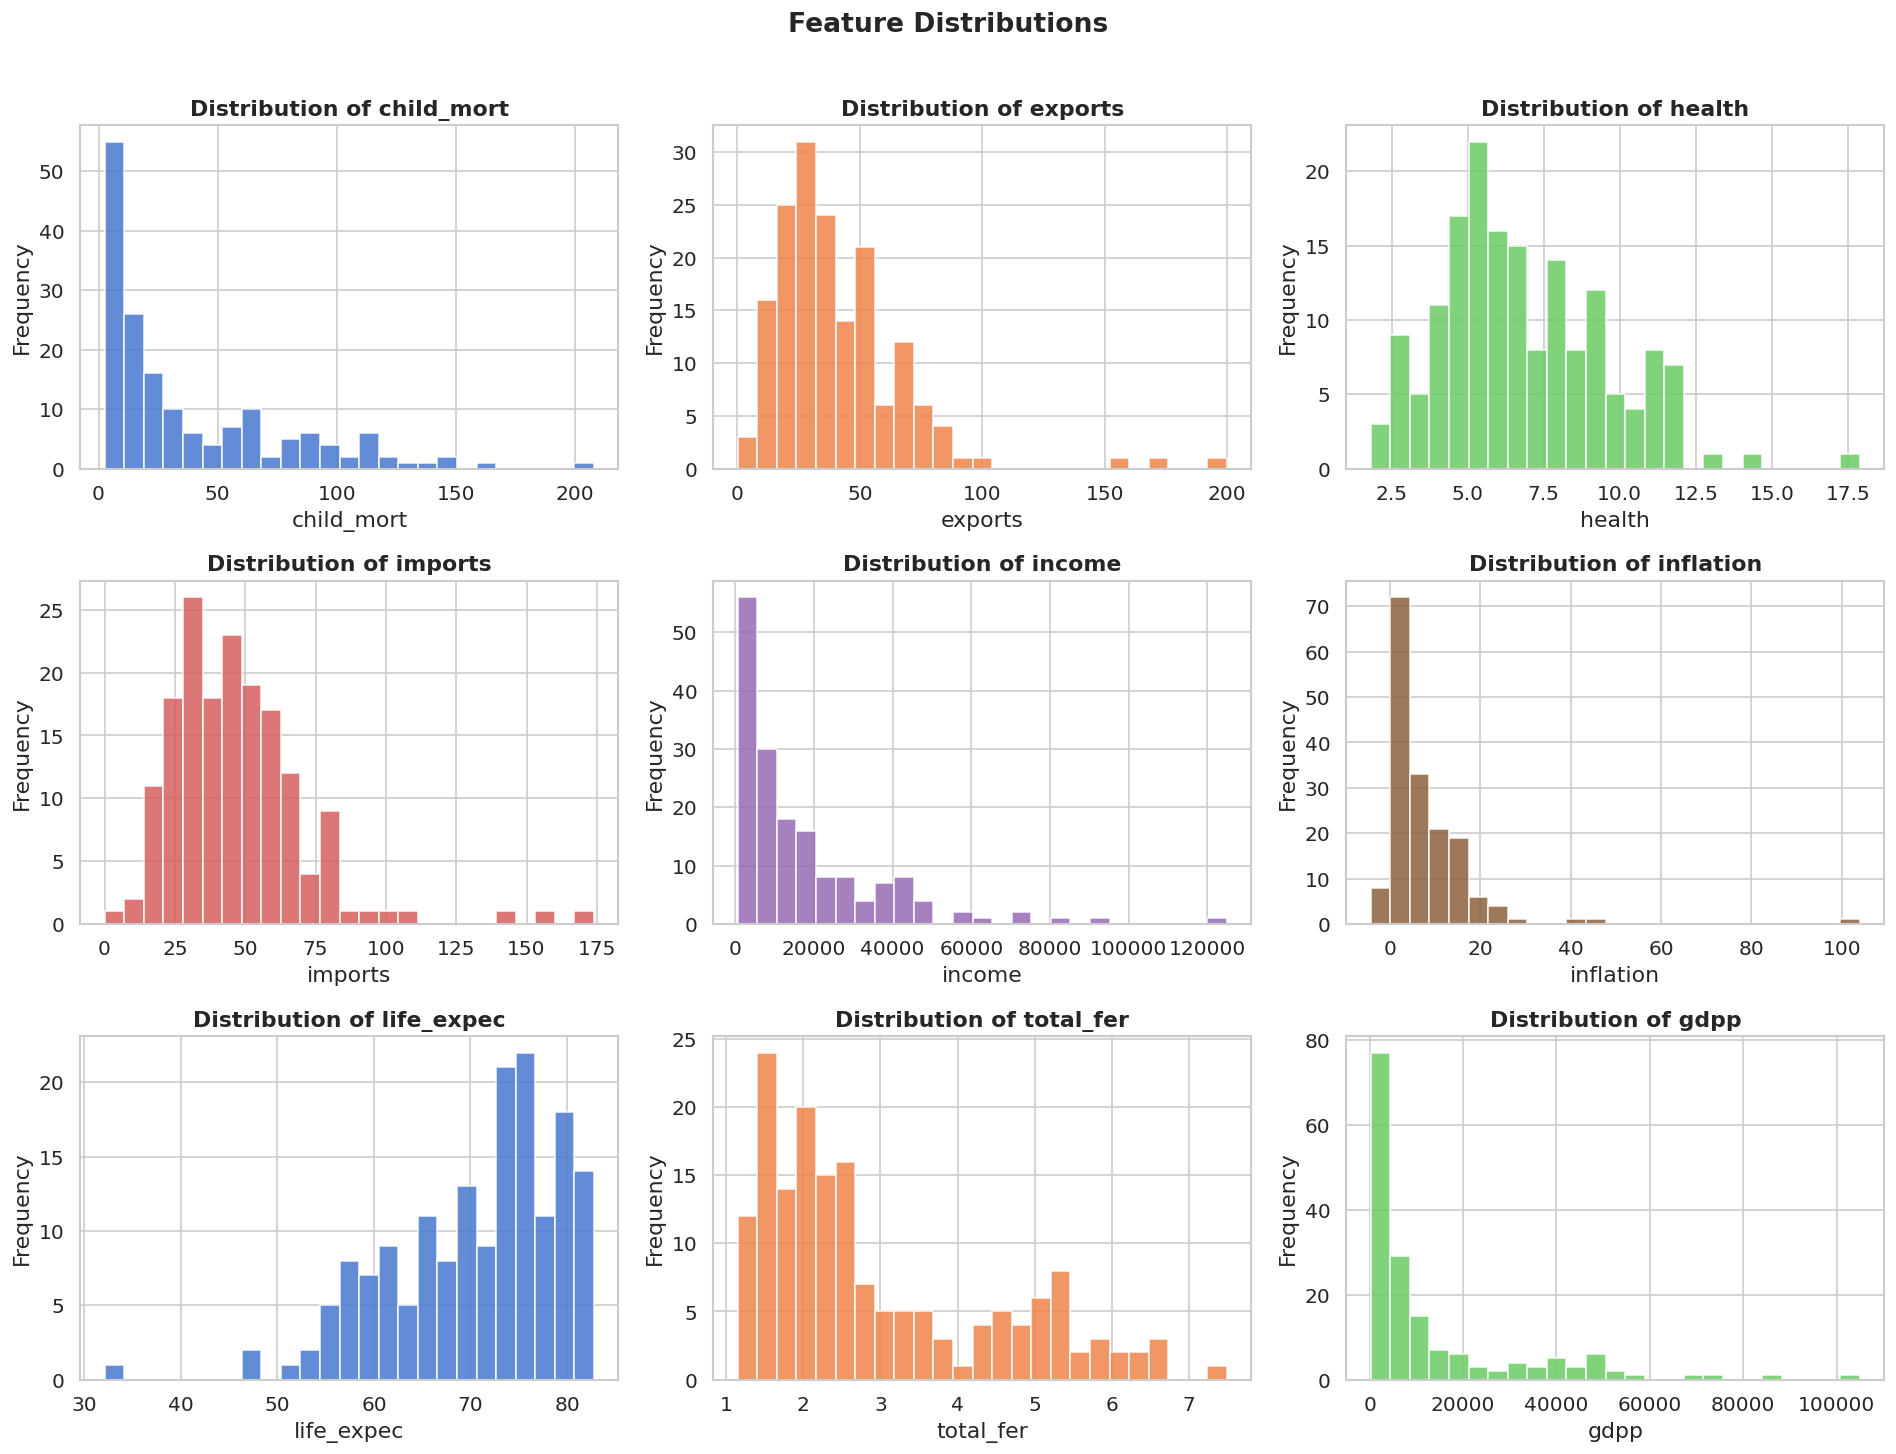

📊 Distribution plots saved.


In [4]:

# Distribution of all numeric features
features = df.select_dtypes(include=np.number).columns.tolist()
fig, axes = plt.subplots(3, 3, figsize=(16, 12))
axes = axes.flatten()

for i, col in enumerate(features):
    axes[i].hist(df[col], bins=25, color=sns.color_palette('muted')[i % 6], edgecolor='white', alpha=0.85)
    axes[i].set_title(f'Distribution of {col}', fontweight='bold')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frequency')

plt.suptitle('Feature Distributions', fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('dist_plots.png', bbox_inches='tight')
plt.show()
print("📊 Distribution plots saved.")


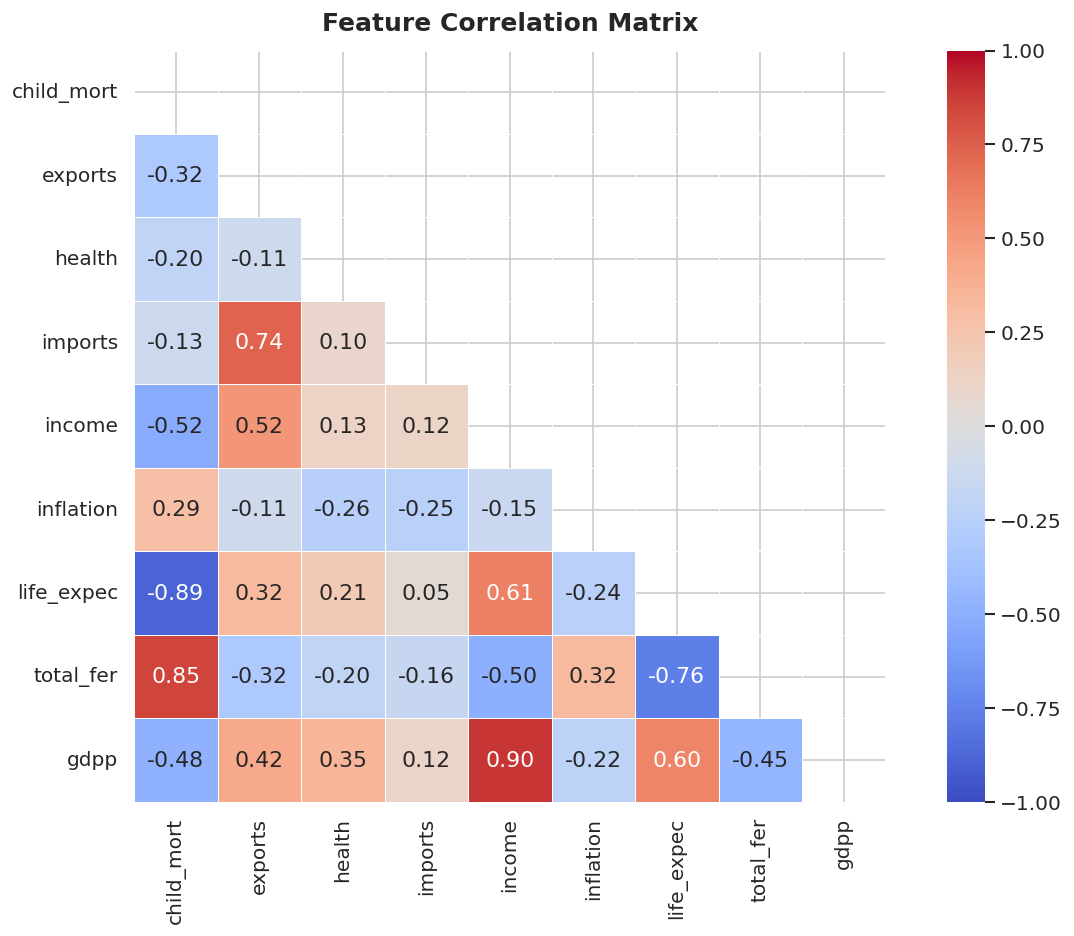


🔗 Top Positive Correlations:
income      gdpp          0.895571
total_fer   child_mort    0.848478
exports     imports       0.737381
life_expec  income        0.611962
gdpp        life_expec    0.600089

🔗 Top Negative Correlations:
child_mort  gdpp         -0.483032
total_fer   income       -0.501840
income      child_mort   -0.524315
total_fer   life_expec   -0.760875
child_mort  life_expec   -0.886676


In [5]:

# Correlation Heatmap
plt.figure(figsize=(11, 8))
corr = df[features].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            linewidths=0.5, vmin=-1, vmax=1, square=True)
plt.title('Feature Correlation Matrix', fontsize=15, fontweight='bold', pad=12)
plt.tight_layout()
plt.savefig('correlation_heatmap.png', bbox_inches='tight')
plt.show()

print("\n🔗 Top Positive Correlations:")
corr_pairs = corr.unstack().sort_values(ascending=False)
corr_pairs = corr_pairs[corr_pairs < 1].drop_duplicates()
print(corr_pairs.head(5).to_string())

print("\n🔗 Top Negative Correlations:")
print(corr_pairs.tail(5).to_string())


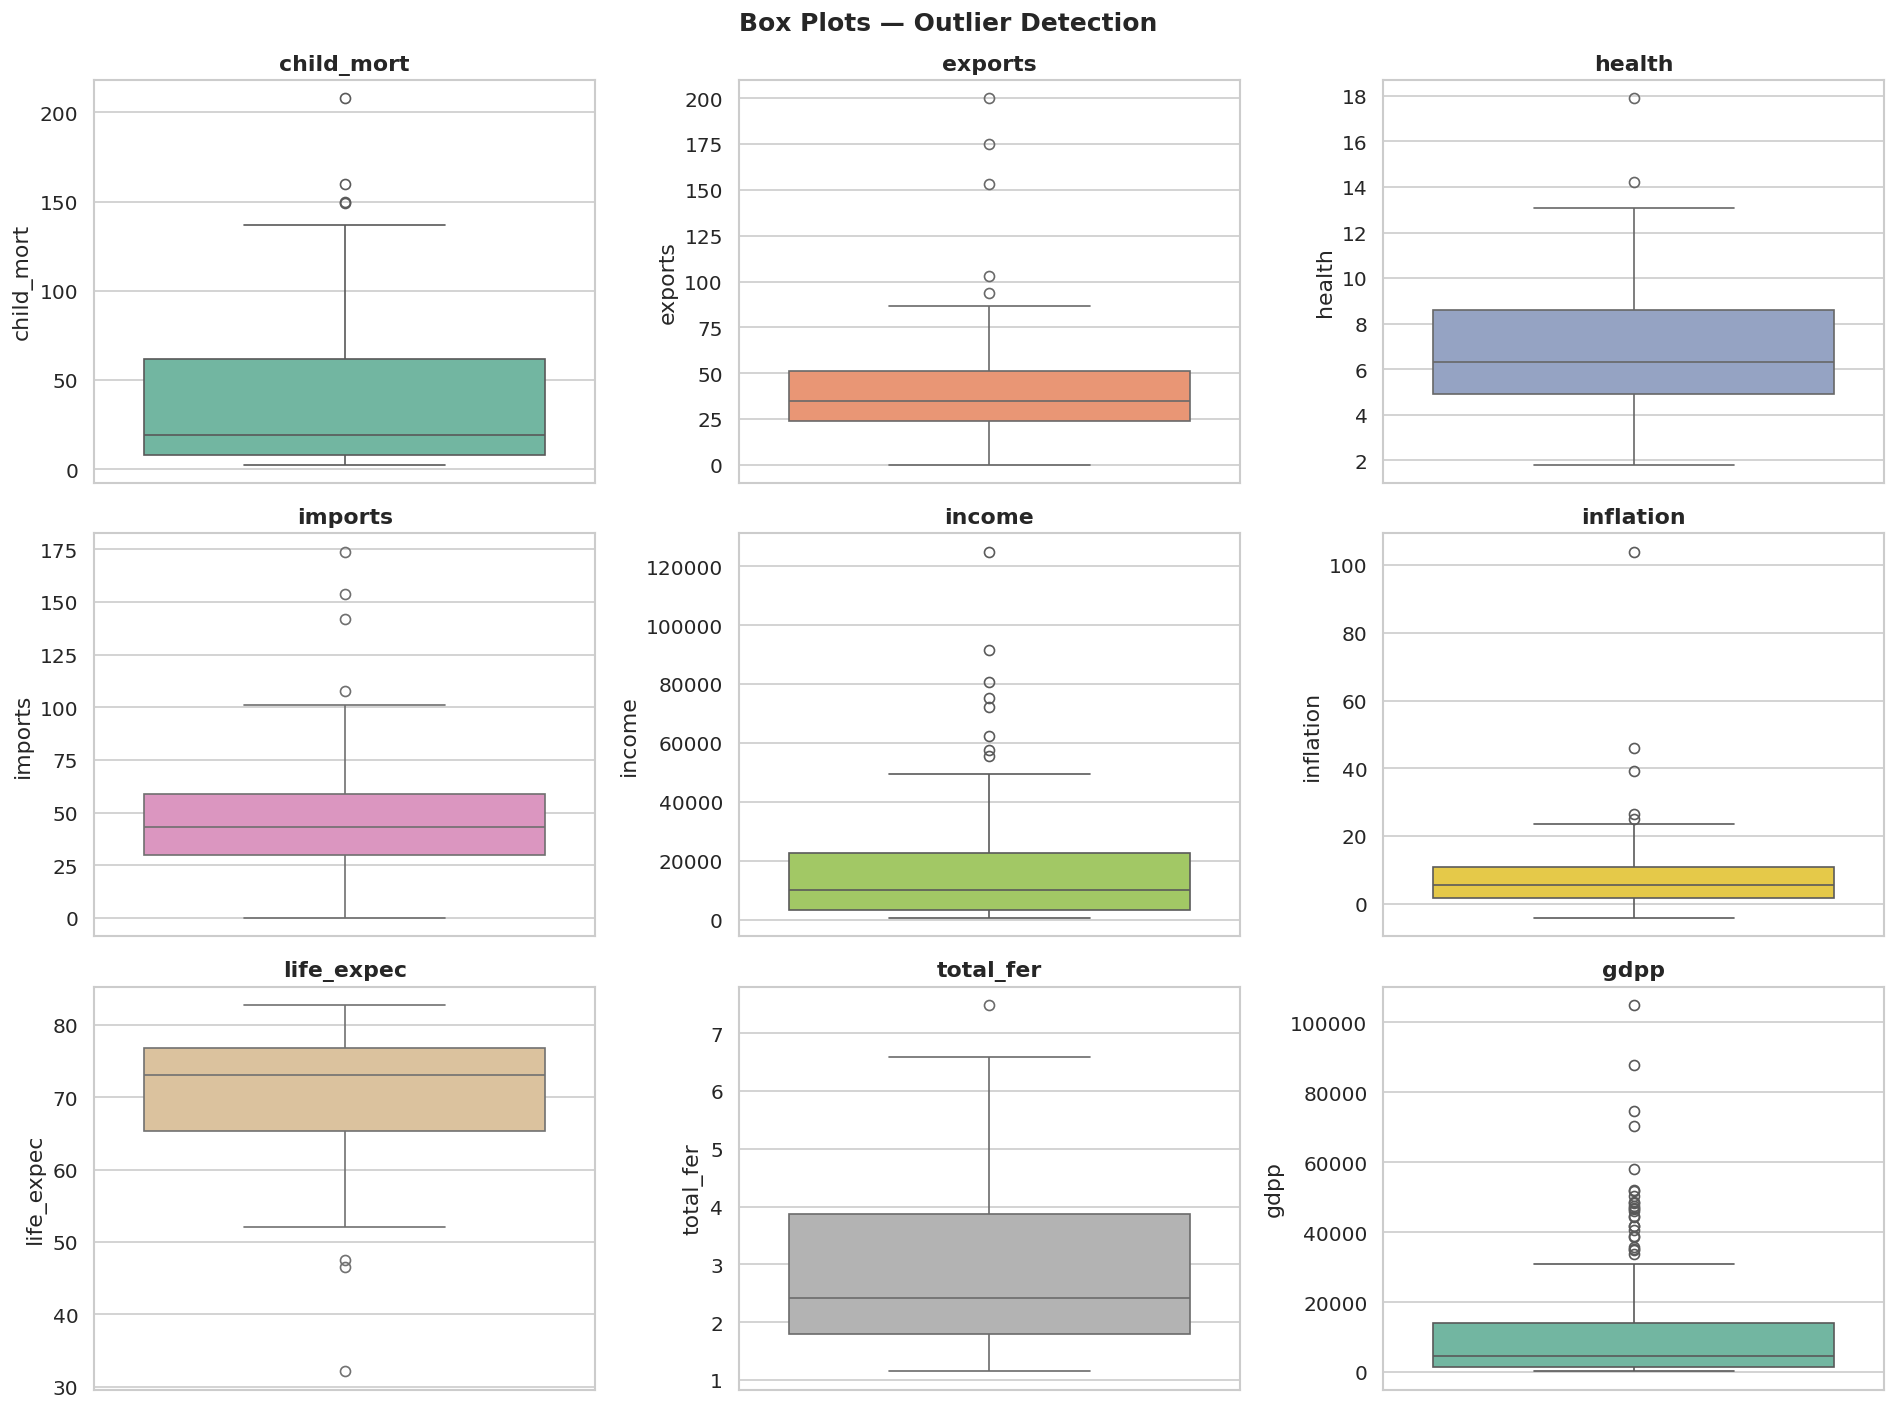

In [6]:

# Box plots for outlier detection
fig, axes = plt.subplots(3, 3, figsize=(16, 12))
axes = axes.flatten()
palette = sns.color_palette('Set2', len(features))

for i, col in enumerate(features):
    sns.boxplot(y=df[col], ax=axes[i], color=palette[i])
    axes[i].set_title(f'{col}', fontweight='bold')

plt.suptitle('Box Plots — Outlier Detection', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('boxplots.png', bbox_inches='tight')
plt.show()


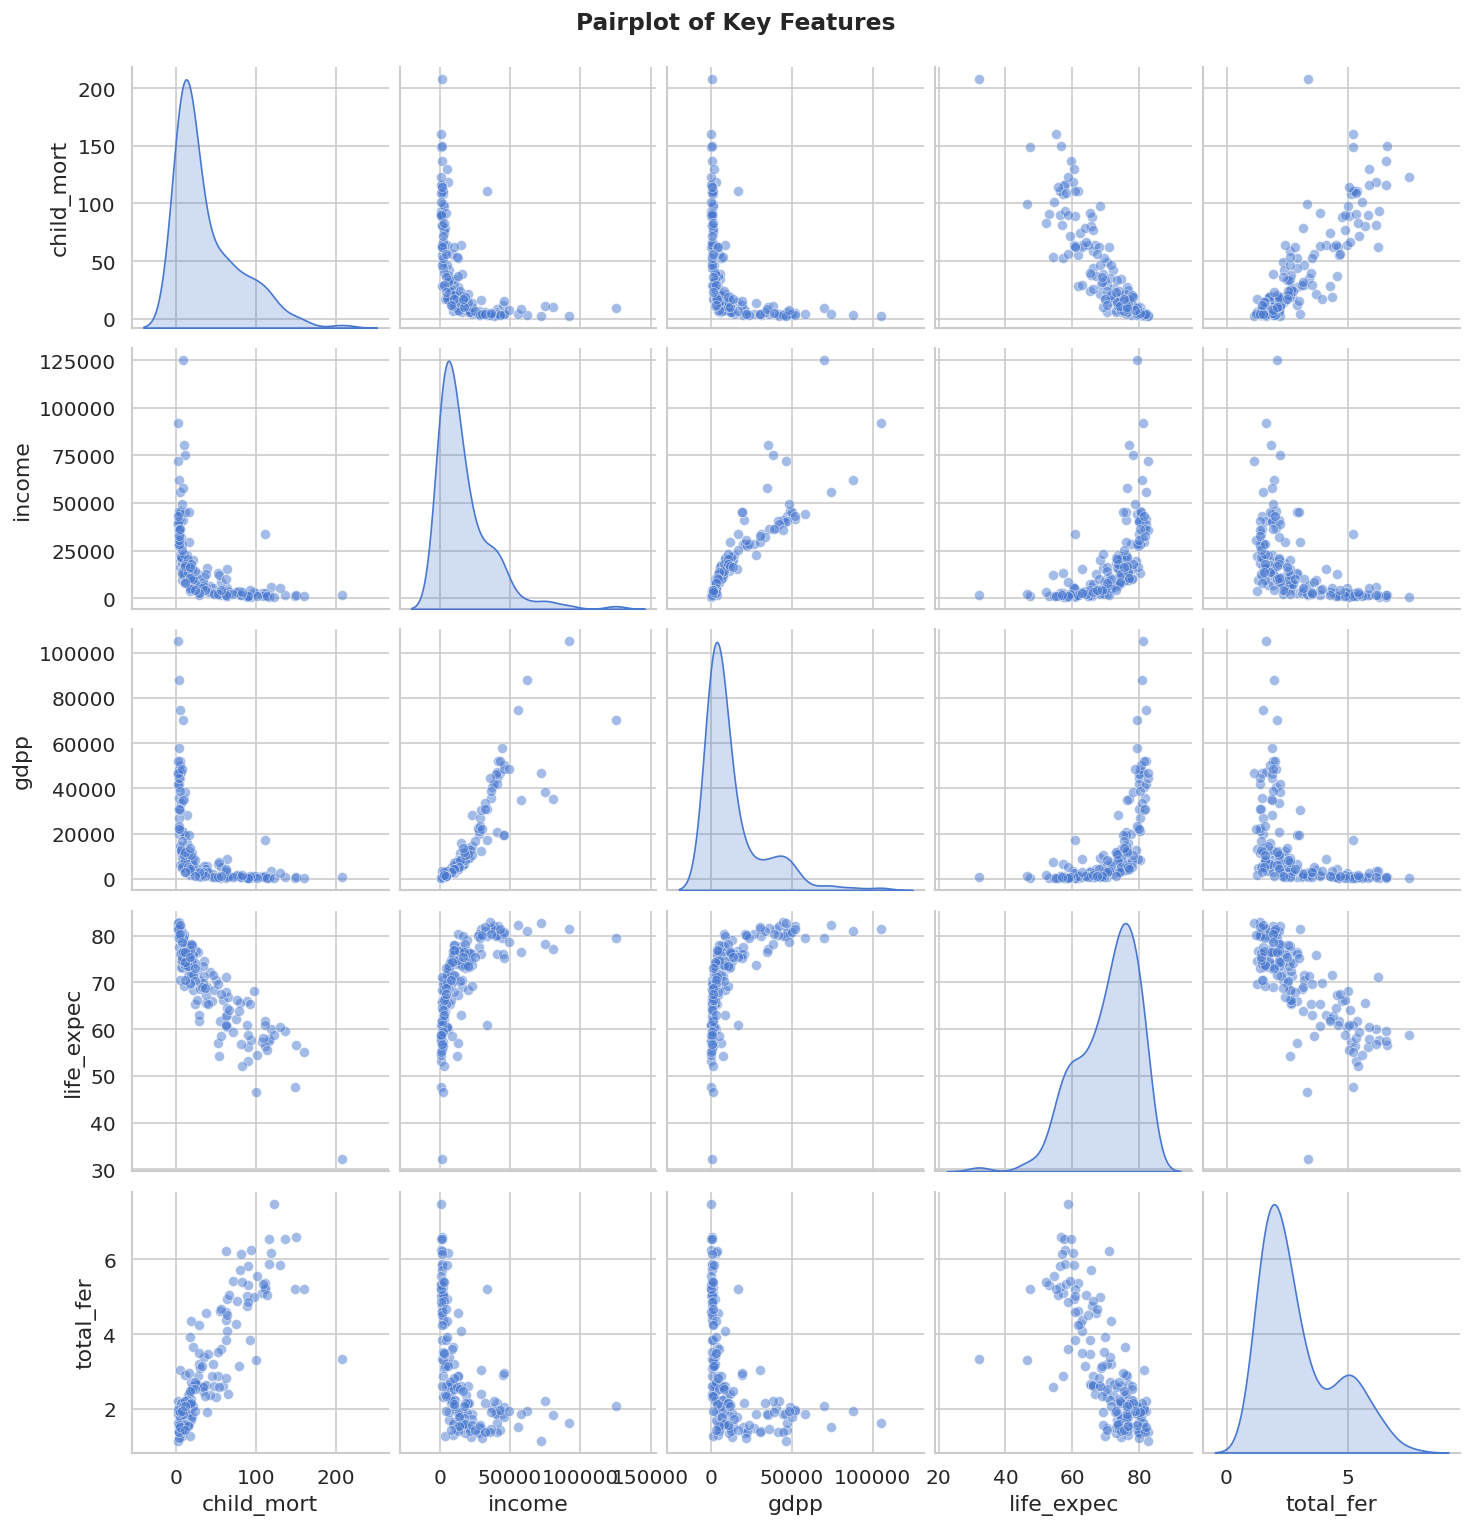

In [7]:

# Pairplot of key features
key_cols = ['child_mort', 'income', 'gdpp', 'life_expec', 'total_fer']
fig = sns.pairplot(df[key_cols], diag_kind='kde', plot_kws={'alpha': 0.5},
                   diag_kws={'fill': True})
fig.figure.suptitle('Pairplot of Key Features', y=1.02, fontsize=14, fontweight='bold')
plt.savefig('pairplot.png', bbox_inches='tight')
plt.show()


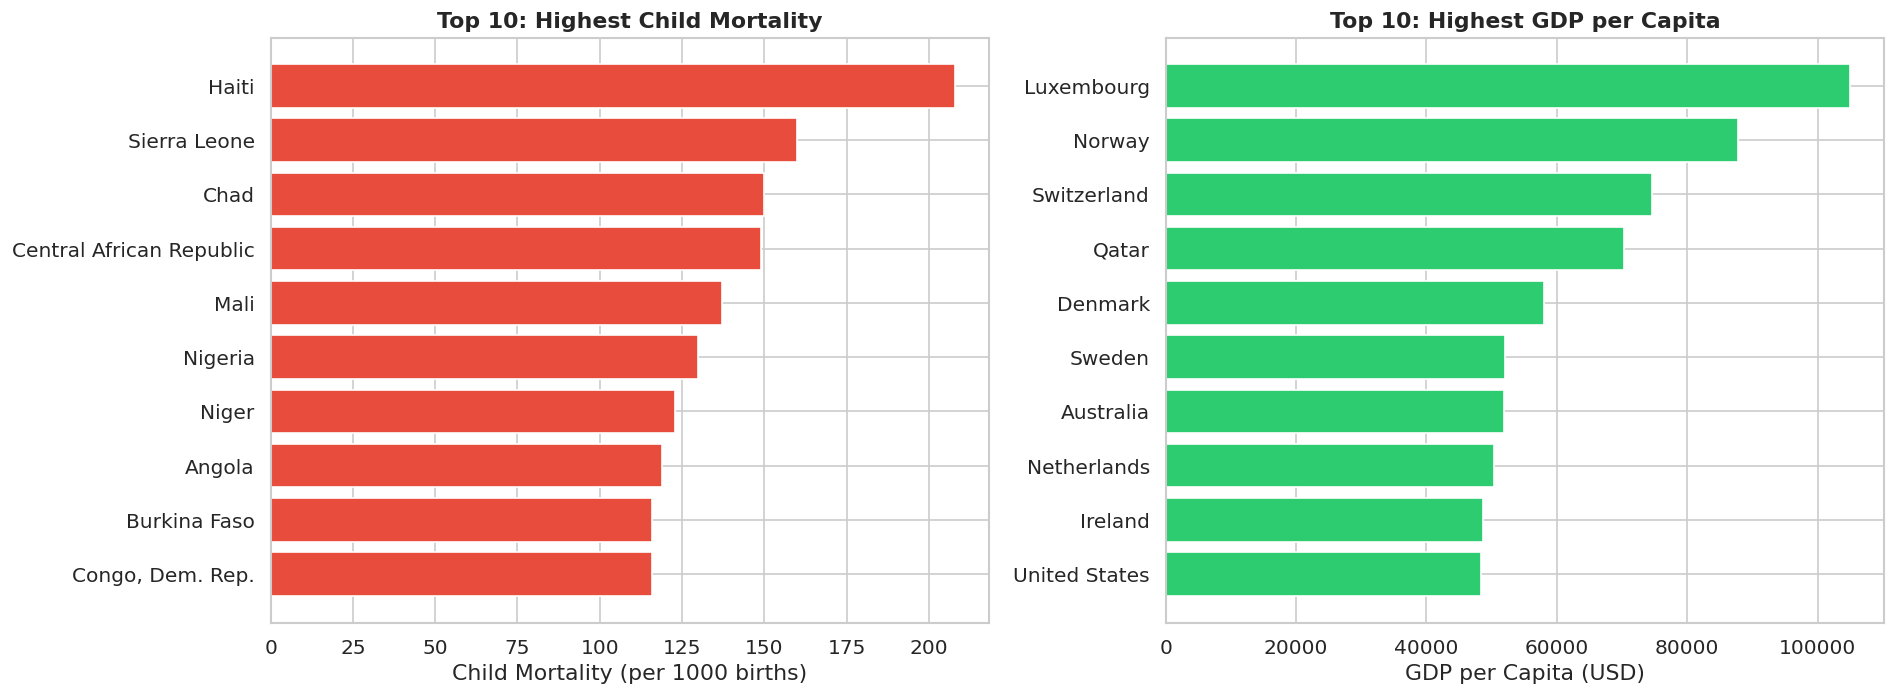

In [8]:

# Top & Bottom countries by key indicators
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Highest child mortality
top_mort = df.nlargest(10, 'child_mort')[['country', 'child_mort']]
axes[0].barh(top_mort['country'], top_mort['child_mort'], color='#e74c3c')
axes[0].set_title('Top 10: Highest Child Mortality', fontweight='bold')
axes[0].set_xlabel('Child Mortality (per 1000 births)')
axes[0].invert_yaxis()

# Highest GDP per capita
top_gdp = df.nlargest(10, 'gdpp')[['country', 'gdpp']]
axes[1].barh(top_gdp['country'], top_gdp['gdpp'], color='#2ecc71')
axes[1].set_title('Top 10: Highest GDP per Capita', fontweight='bold')
axes[1].set_xlabel('GDP per Capita (USD)')
axes[1].invert_yaxis()

plt.tight_layout()
plt.savefig('top_countries.png', bbox_inches='tight')
plt.show()


## 4. ⚙️ Data Preprocessing & Feature Engineering

✅ Winsorization applied (factor=3×IQR) on 9 features.
✅ StandardScaler applied. Shape: (167, 9)

📐 PCA 2D Explained Variance: 64.0%
📐 PCA 3D Explained Variance: 77.5%


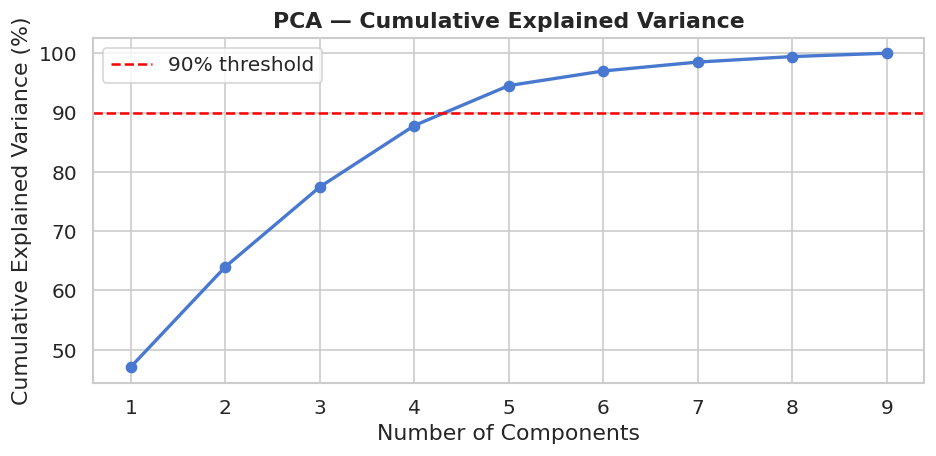

In [9]:

# ── Feature matrix ────────────────────────────────────────────────────────
X_raw = df[features].copy()
country_names = df['country'].values

# ── Outlier capping (IQR Winsorization) ──────────────────────────────────
def winsorize_df(df_in, cols, factor=3.0):
    df_out = df_in.copy()
    for col in cols:
        Q1, Q3 = df_out[col].quantile(0.25), df_out[col].quantile(0.75)
        IQR = Q3 - Q1
        df_out[col] = df_out[col].clip(Q1 - factor*IQR, Q3 + factor*IQR)
    return df_out

X_winsorized = winsorize_df(X_raw, features)
print(f"✅ Winsorization applied (factor=3×IQR) on {len(features)} features.")

# ── Standard Scaling ──────────────────────────────────────────────────────
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_winsorized)
X_scaled_df = pd.DataFrame(X_scaled, columns=features)
print(f"✅ StandardScaler applied. Shape: {X_scaled.shape}")

# ── PCA for visualization ─────────────────────────────────────────────────
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

pca3 = PCA(n_components=3, random_state=42)
X_pca3 = pca3.fit_transform(X_scaled)

print(f"\n📐 PCA 2D Explained Variance: {pca.explained_variance_ratio_.sum()*100:.1f}%")
print(f"📐 PCA 3D Explained Variance: {pca3.explained_variance_ratio_.sum()*100:.1f}%")

# Explained variance plot
plt.figure(figsize=(8,4))
pca_full = PCA(random_state=42).fit(X_scaled)
cumvar = np.cumsum(pca_full.explained_variance_ratio_) * 100
plt.plot(range(1, len(cumvar)+1), cumvar, 'bo-', linewidth=2)
plt.axhline(90, color='red', linestyle='--', label='90% threshold')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance (%)')
plt.title('PCA — Cumulative Explained Variance', fontweight='bold')
plt.legend()
plt.tight_layout()
plt.savefig('pca_variance.png', bbox_inches='tight')
plt.show()


## 5. 🔵 Clustering Analysis

### 5.1 K-Means — Optimal K (Elbow + Silhouette)

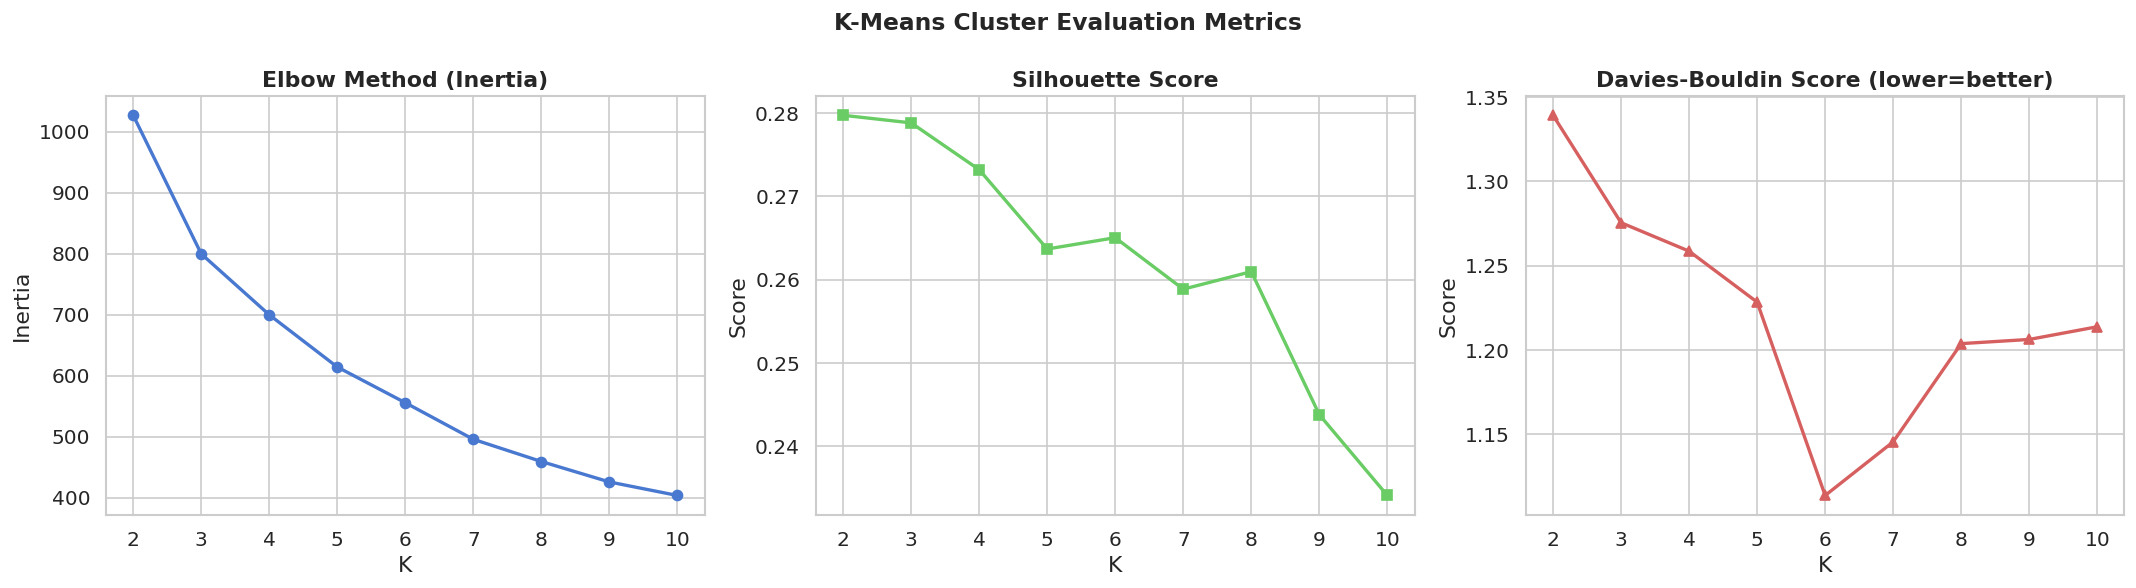


✅ Optimal K = 2  |  Silhouette = 0.2797


In [10]:

inertias, sil_scores, db_scores = [], [], []
K_range = range(2, 11)

for k in K_range:
    km = KMeans(n_clusters=k, n_init=15, random_state=42)
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(X_scaled, labels))
    db_scores.append(davies_bouldin_score(X_scaled, labels))

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].plot(K_range, inertias, 'bo-', linewidth=2)
axes[0].set_title('Elbow Method (Inertia)', fontweight='bold')
axes[0].set_xlabel('K'); axes[0].set_ylabel('Inertia')

axes[1].plot(K_range, sil_scores, 'gs-', linewidth=2)
axes[1].set_title('Silhouette Score', fontweight='bold')
axes[1].set_xlabel('K'); axes[1].set_ylabel('Score')

axes[2].plot(K_range, db_scores, 'r^-', linewidth=2)
axes[2].set_title('Davies-Bouldin Score (lower=better)', fontweight='bold')
axes[2].set_xlabel('K'); axes[2].set_ylabel('Score')

plt.suptitle('K-Means Cluster Evaluation Metrics', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('kmeans_eval.png', bbox_inches='tight')
plt.show()

best_k = K_range[np.argmax(sil_scores)]
print(f"\n✅ Optimal K = {best_k}  |  Silhouette = {max(sil_scores):.4f}")


### 5.2 Final K-Means Model (K=3)

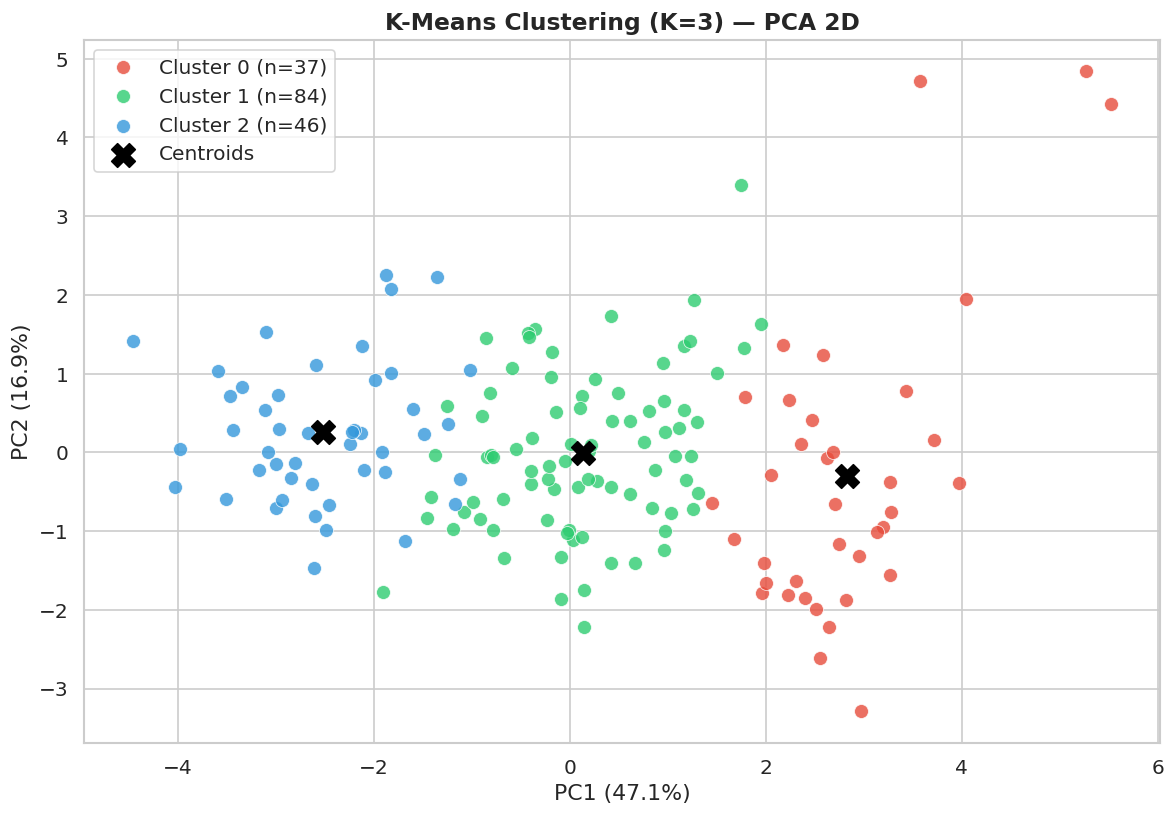

Silhouette Score (K=3): 0.2788
Davies-Bouldin Score : 1.2755


In [11]:

OPTIMAL_K = 3  # Interpretable: Developed / Developing / Underdeveloped

kmeans = KMeans(n_clusters=OPTIMAL_K, n_init=20, random_state=42)
km_labels = kmeans.fit_predict(X_scaled)

df['KMeans_Cluster'] = km_labels

# PCA 2D visualization
plt.figure(figsize=(10, 7))
palette = ['#e74c3c', '#2ecc71', '#3498db']
cluster_names = {0: 'Cluster 0', 1: 'Cluster 1', 2: 'Cluster 2'}

for c in range(OPTIMAL_K):
    mask = km_labels == c
    plt.scatter(X_pca[mask, 0], X_pca[mask, 1],
                c=palette[c], label=f'Cluster {c} (n={mask.sum()})',
                s=70, alpha=0.8, edgecolors='white', linewidths=0.5)

centers_pca = pca.transform(kmeans.cluster_centers_)
plt.scatter(centers_pca[:, 0], centers_pca[:, 1],
            c='black', marker='X', s=200, zorder=5, label='Centroids')

plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
plt.title('K-Means Clustering (K=3) — PCA 2D', fontsize=14, fontweight='bold')
plt.legend()
plt.tight_layout()
plt.savefig('kmeans_clusters.png', bbox_inches='tight')
plt.show()

print(f"Silhouette Score (K=3): {silhouette_score(X_scaled, km_labels):.4f}")
print(f"Davies-Bouldin Score : {davies_bouldin_score(X_scaled, km_labels):.4f}")


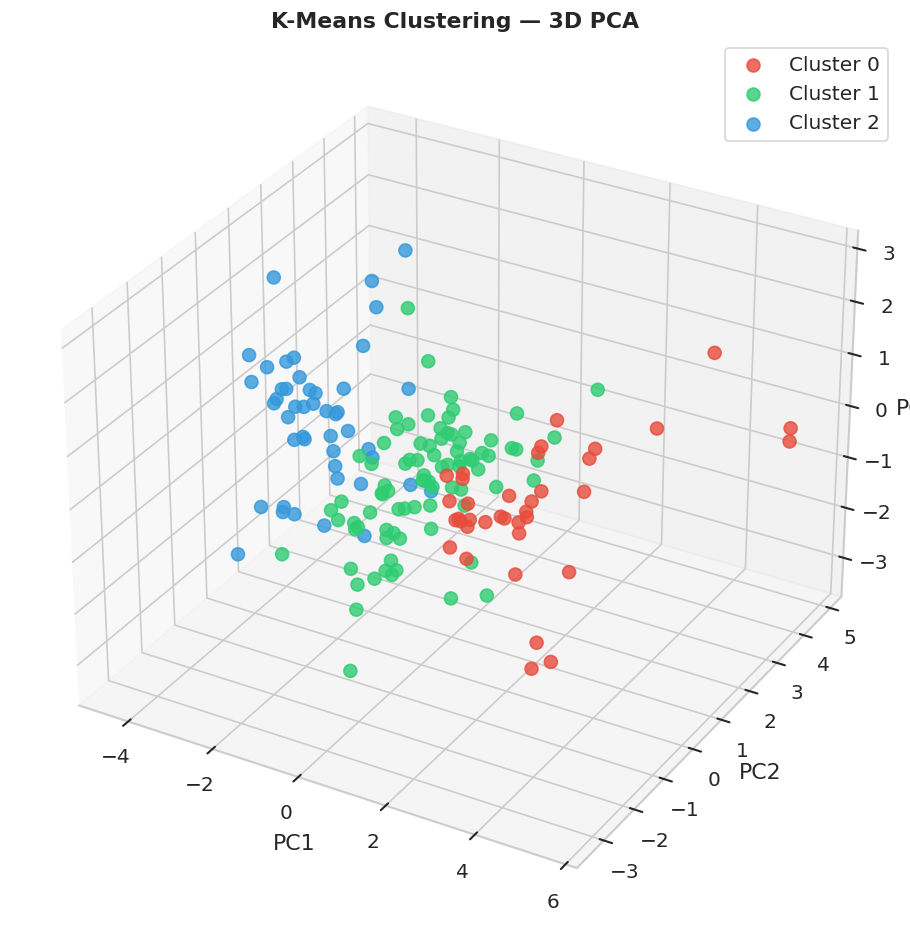

In [12]:

# 3D PCA Cluster Visualization
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')

for c in range(OPTIMAL_K):
    mask = km_labels == c
    ax.scatter(X_pca3[mask, 0], X_pca3[mask, 1], X_pca3[mask, 2],
               c=palette[c], label=f'Cluster {c}', s=60, alpha=0.8)

ax.set_xlabel('PC1'); ax.set_ylabel('PC2'); ax.set_zlabel('PC3')
ax.set_title('K-Means Clustering — 3D PCA', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig('kmeans_3d.png', bbox_inches='tight')
plt.show()


,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
KMeans_Cluster,,,,,,,,,
0,5.240000,58.100000,8.780000,51.280000,45056.760000,2.590000,79.960000,1.760000,42102.700000
1,22.390000,40.350000,6.210000,47.560000,12191.310000,7.710000,72.620000,2.320000,6228.710000
2,93.840000,28.840000,6.350000,42.130000,3738.980000,12.090000,59.230000,5.050000,1826.130000


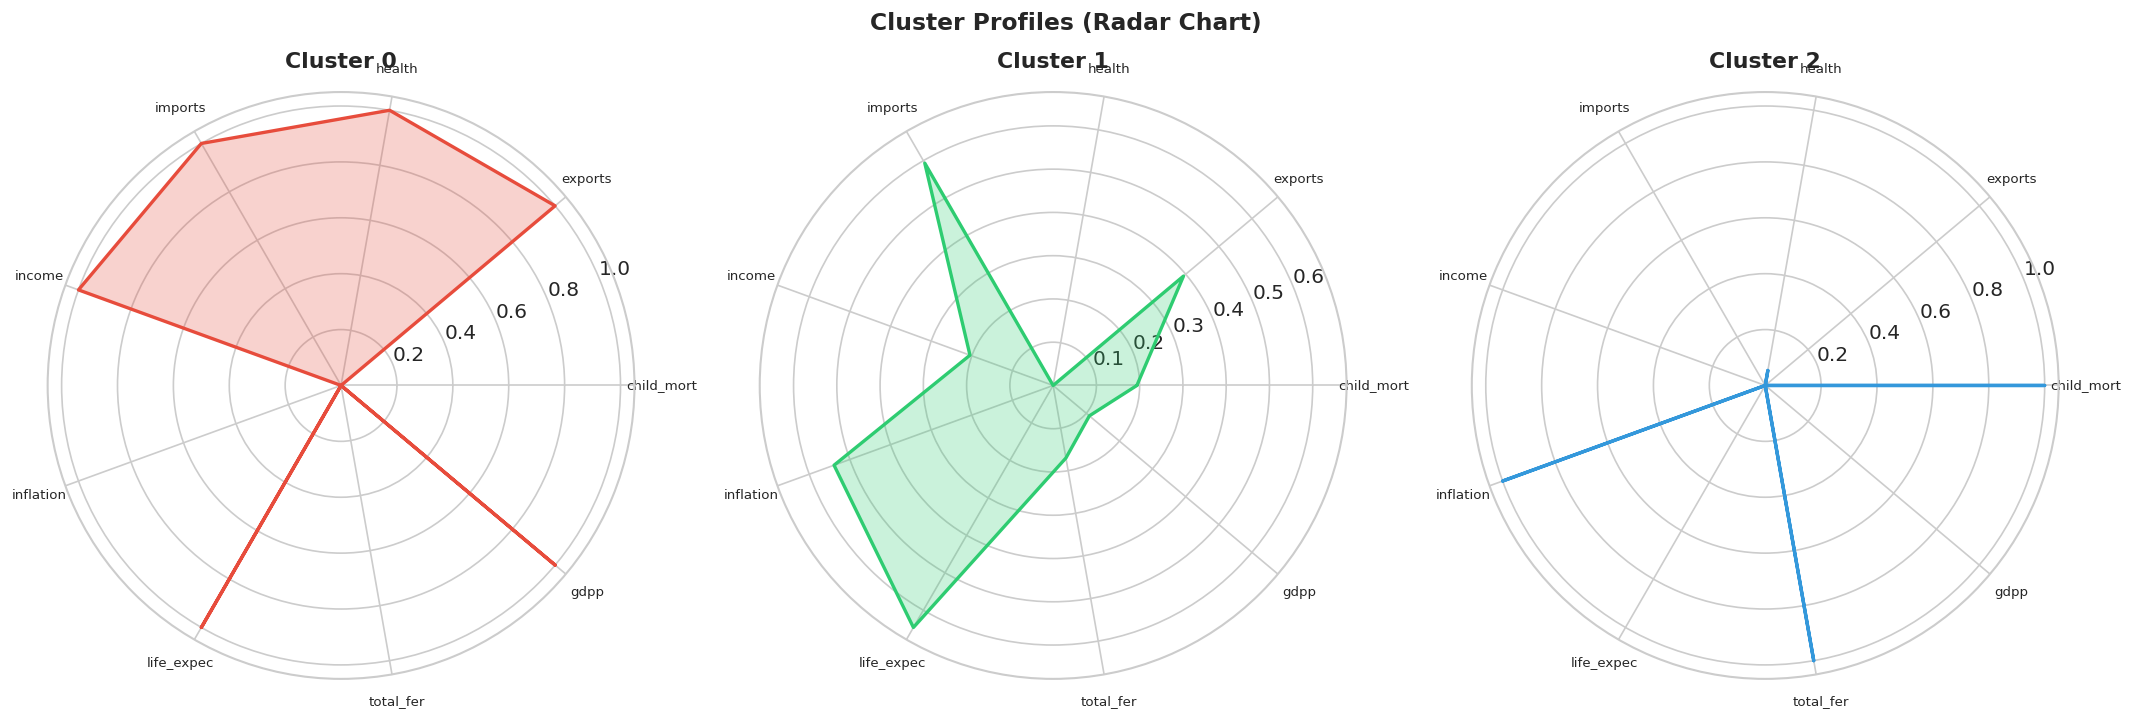

In [13]:

# Cluster profile: mean features per cluster
cluster_profile = df.groupby('KMeans_Cluster')[features].mean().round(2)
display(cluster_profile.style.background_gradient(cmap='RdYlGn', axis=0))

# Radar chart per cluster
from matplotlib.patches import FancyArrowPatch

categories = features
N = len(categories)
angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
angles += angles[:1]

fig, axes = plt.subplots(1, OPTIMAL_K, figsize=(18, 6), subplot_kw=dict(polar=True))

normalized = (cluster_profile - cluster_profile.min()) / (cluster_profile.max() - cluster_profile.min() + 1e-9)

for i, ax in enumerate(axes):
    values = normalized.iloc[i].tolist()
    values += values[:1]
    ax.plot(angles, values, color=palette[i], linewidth=2)
    ax.fill(angles, values, color=palette[i], alpha=0.25)
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(categories, size=8)
    ax.set_title(f'Cluster {i}', fontweight='bold', pad=15)

plt.suptitle('Cluster Profiles (Radar Chart)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('radar_chart.png', bbox_inches='tight')
plt.show()


In [14]:

# Countries per cluster
print("\n🌍 COUNTRIES BY K-MEANS CLUSTER")
print("=" * 70)
for c in range(OPTIMAL_K):
    countries = df[df['KMeans_Cluster'] == c]['country'].tolist()
    avg_gdp = df[df['KMeans_Cluster'] == c]['gdpp'].mean()
    avg_mort = df[df['KMeans_Cluster'] == c]['child_mort'].mean()
    print(f"\nCluster {c} — {len(countries)} countries | Avg GDP: ${avg_gdp:,.0f} | Avg Child Mort: {avg_mort:.1f}")
    print(", ".join(sorted(countries)))



🌍 COUNTRIES BY K-MEANS CLUSTER

Cluster 0 — 37 countries | Avg GDP: $42,103 | Avg Child Mort: 5.2
Australia, Austria, Bahamas, Bahrain, Belgium, Brunei, Canada, Cyprus, Czech Republic, Denmark, Finland, France, Germany, Greece, Iceland, Ireland, Israel, Italy, Japan, Kuwait, Luxembourg, Malta, Netherlands, New Zealand, Norway, Portugal, Qatar, Singapore, Slovak Republic, Slovenia, South Korea, Spain, Sweden, Switzerland, United Arab Emirates, United Kingdom, United States

Cluster 1 — 84 countries | Avg GDP: $6,229 | Avg Child Mort: 22.4
Albania, Algeria, Antigua and Barbuda, Argentina, Armenia, Azerbaijan, Bangladesh, Barbados, Belarus, Belize, Bhutan, Bolivia, Bosnia and Herzegovina, Botswana, Brazil, Bulgaria, Cambodia, Cape Verde, Chile, China, Colombia, Costa Rica, Croatia, Dominican Republic, Ecuador, Egypt, El Salvador, Estonia, Fiji, Georgia, Grenada, Guatemala, Guyana, Hungary, India, Indonesia, Iran, Jamaica, Jordan, Kazakhstan, Kyrgyz Republic, Latvia, Lebanon, Libya, Lithu

### 5.3 DBSCAN Clustering

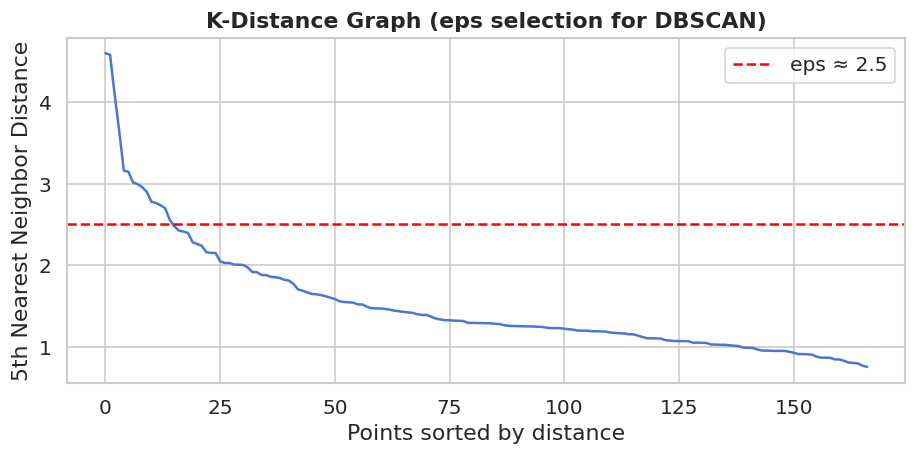

DBSCAN Clusters Found : 1
Noise Points (label=-1): 7
Cluster sizes: {0: 160, -1: 7}


In [15]:

from sklearn.neighbors import NearestNeighbors

# K-distance plot to find optimal eps
nn = NearestNeighbors(n_neighbors=5)
nn.fit(X_scaled)
distances, _ = nn.kneighbors(X_scaled)
k_dist = np.sort(distances[:, -1])[::-1]

plt.figure(figsize=(8, 4))
plt.plot(k_dist, 'b-', linewidth=1.5)
plt.axhline(2.5, color='red', linestyle='--', label='eps ≈ 2.5')
plt.title('K-Distance Graph (eps selection for DBSCAN)', fontweight='bold')
plt.xlabel('Points sorted by distance')
plt.ylabel('5th Nearest Neighbor Distance')
plt.legend()
plt.tight_layout()
plt.savefig('dbscan_kdist.png', bbox_inches='tight')
plt.show()

# Fit DBSCAN
dbscan = DBSCAN(eps=2.5, min_samples=4)
db_labels = dbscan.fit_predict(X_scaled)
df['DBSCAN_Cluster'] = db_labels

n_clusters_db = len(set(db_labels)) - (1 if -1 in db_labels else 0)
n_noise = (db_labels == -1).sum()

print(f"DBSCAN Clusters Found : {n_clusters_db}")
print(f"Noise Points (label=-1): {n_noise}")
print("Cluster sizes:", pd.Series(db_labels).value_counts().to_dict())


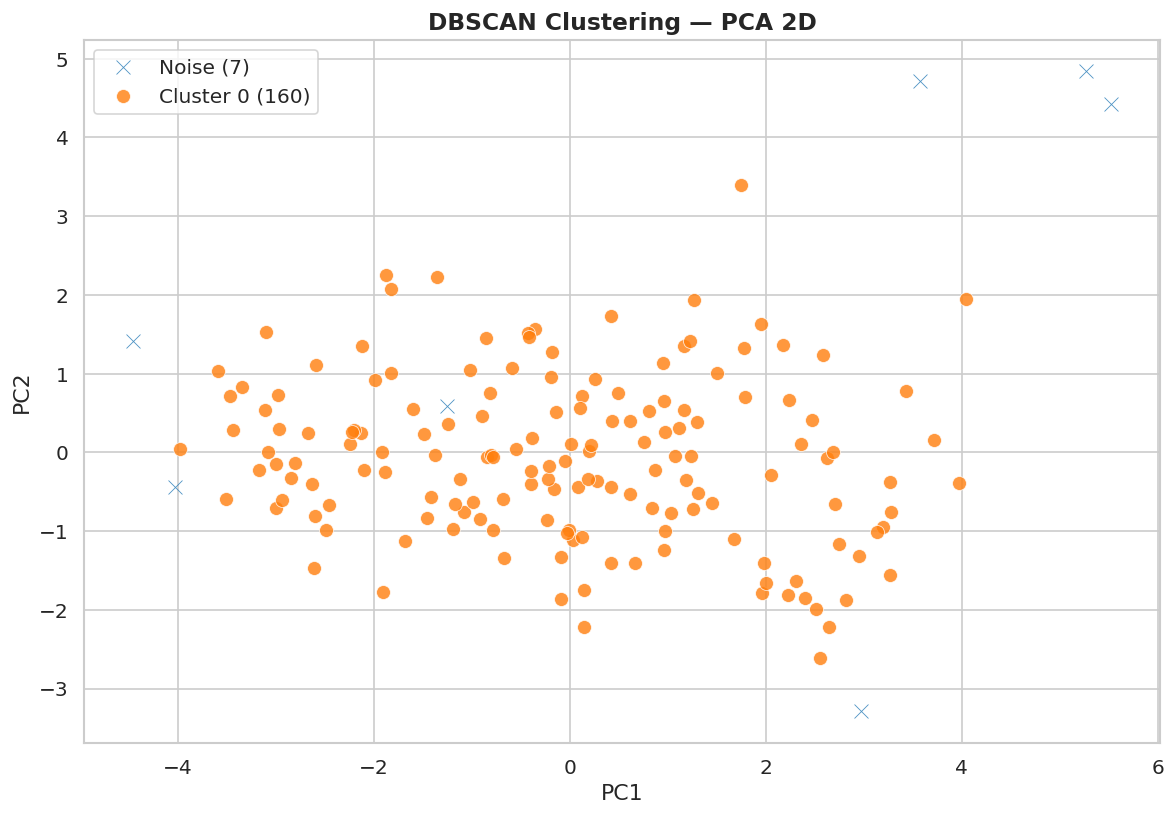

In [16]:

# DBSCAN visualization
plt.figure(figsize=(10, 7))
unique_labels = sorted(set(db_labels))
db_palette = sns.color_palette('tab10', len(unique_labels))

for i, label in enumerate(unique_labels):
    mask = db_labels == label
    lname = f'Noise ({mask.sum()})' if label == -1 else f'Cluster {label} ({mask.sum()})'
    marker = 'x' if label == -1 else 'o'
    plt.scatter(X_pca[mask, 0], X_pca[mask, 1],
                c=[db_palette[i]], label=lname,
                s=70, alpha=0.8, marker=marker, edgecolors='white', linewidths=0.5)

plt.title('DBSCAN Clustering — PCA 2D', fontsize=14, fontweight='bold')
plt.xlabel('PC1'); plt.ylabel('PC2')
plt.legend()
plt.tight_layout()
plt.savefig('dbscan_clusters.png', bbox_inches='tight')
plt.show()


### 5.4 Hierarchical Clustering (Dendrogram)

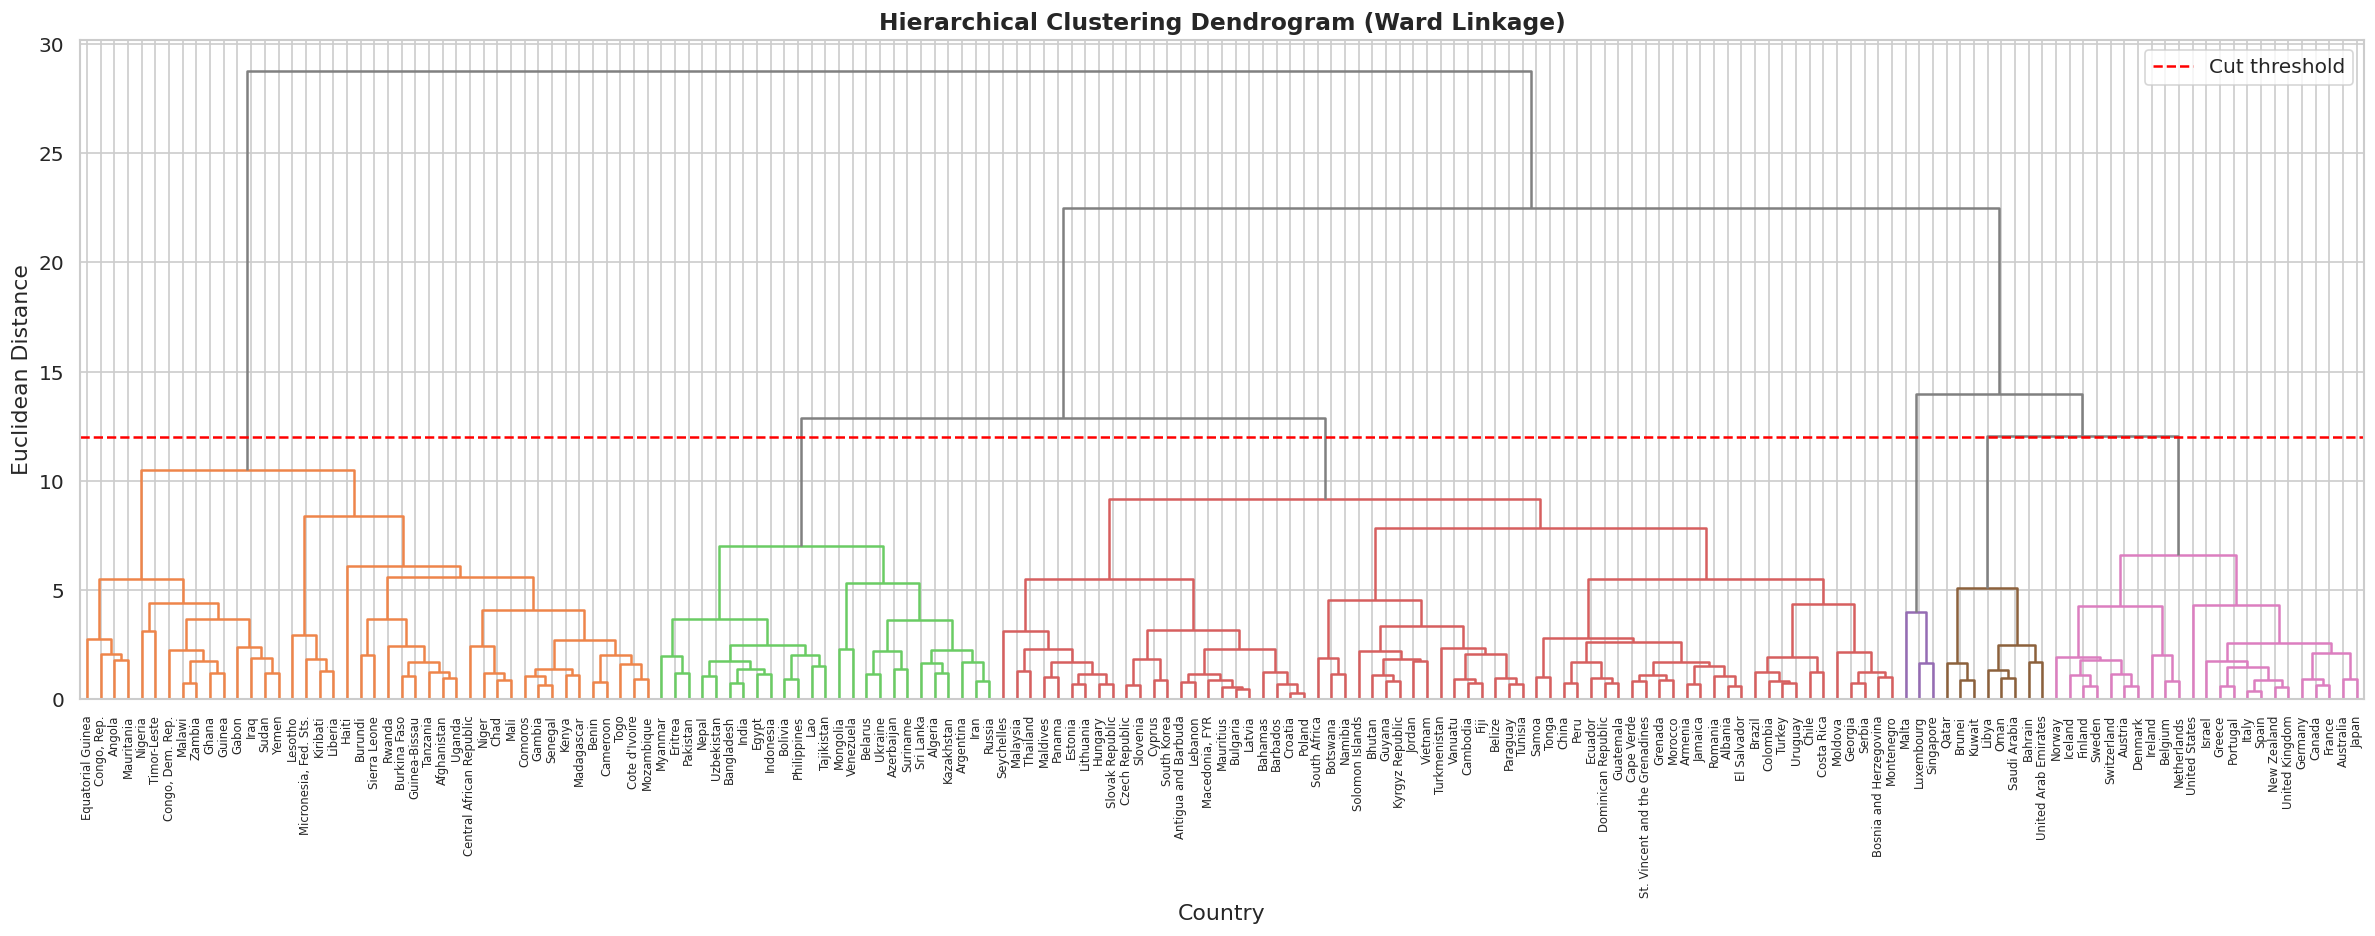

In [17]:

plt.figure(figsize=(20, 8))
linked = linkage(X_scaled, method='ward')
dendrogram(linked,
           labels=country_names,
           leaf_rotation=90,
           leaf_font_size=7,
           color_threshold=12,
           above_threshold_color='gray')
plt.title('Hierarchical Clustering Dendrogram (Ward Linkage)', fontsize=14, fontweight='bold')
plt.xlabel('Country')
plt.ylabel('Euclidean Distance')
plt.axhline(12, color='red', linestyle='--', linewidth=1.5, label='Cut threshold')
plt.legend()
plt.tight_layout()
plt.savefig('dendrogram.png', bbox_inches='tight')
plt.show()


### 5.5 Country Development Category Labeling

Cluster means for label assignment:
                child_mort          gdpp        income
KMeans_Cluster                                        
0                 5.237838  42102.702703  45056.756757
1                22.388095   6228.714286  12191.309524
2                93.841304   1826.130435   3738.978261

Development Category Distribution:
Development_Category
Developing        84
Underdeveloped    46
Developed         37
Name: count, dtype: int64


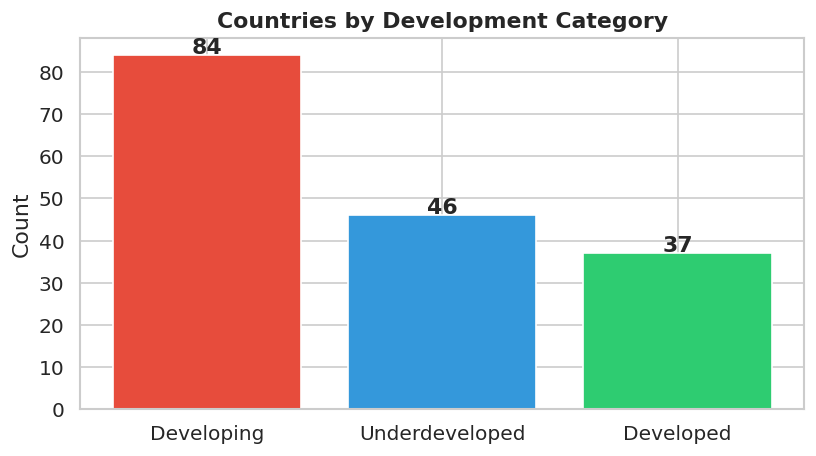

In [18]:

# Assign interpretable labels based on cluster profile
cluster_profile_tmp = df.groupby('KMeans_Cluster')[['child_mort', 'gdpp', 'income']].mean()
print("Cluster means for label assignment:")
print(cluster_profile_tmp)

# Assign based on GDP & child mortality
def assign_label(row):
    c = row['KMeans_Cluster']
    avg_gdp = cluster_profile_tmp.loc[c, 'gdpp']
    avg_mort = cluster_profile_tmp.loc[c, 'child_mort']
    if avg_mort > 60 and avg_gdp < 5000:
        return 'Underdeveloped'
    elif avg_mort < 20 and avg_gdp > 15000:
        return 'Developed'
    else:
        return 'Developing'

df['Development_Category'] = df.apply(assign_label, axis=1)
print("\nDevelopment Category Distribution:")
print(df['Development_Category'].value_counts())

# Bar chart of category counts
plt.figure(figsize=(7, 4))
cat_counts = df['Development_Category'].value_counts()
bars = plt.bar(cat_counts.index, cat_counts.values,
               color=['#e74c3c','#3498db','#2ecc71'][:len(cat_counts)])
for bar, val in zip(bars, cat_counts.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
             str(val), ha='center', fontweight='bold')
plt.title('Countries by Development Category', fontweight='bold')
plt.ylabel('Count')
plt.tight_layout()
plt.savefig('dev_category.png', bbox_inches='tight')
plt.show()


## 6. 🤖 Supervised Classification

### 6.1 Prepare Classification Dataset

In [19]:

# Encode target
le = LabelEncoder()
y = le.fit_transform(df['Development_Category'])
print("Classes:", le.classes_, "→ Labels:", np.unique(y))

X_clf = X_scaled.copy()

X_train, X_test, y_train, y_test = train_test_split(
    X_clf, y, test_size=0.2, random_state=42, stratify=y)

print(f"\nTrain: {X_train.shape[0]} samples | Test: {X_test.shape[0]} samples")
print("Train label distribution:", dict(zip(le.classes_, np.bincount(y_train))))
print("Test label distribution :", dict(zip(le.classes_, np.bincount(y_test))))


Classes: ['Developed' 'Developing' 'Underdeveloped'] → Labels: [0 1 2]

Train: 133 samples | Test: 34 samples
Train label distribution: {'Developed': np.int64(29), 'Developing': np.int64(67), 'Underdeveloped': np.int64(37)}
Test label distribution : {'Developed': np.int64(8), 'Developing': np.int64(17), 'Underdeveloped': np.int64(9)}


### 6.2 Baseline Models Comparison

Model                       CV Acc     Std   Test Acc
-------------------------------------------------------
Logistic Regression         0.9621  0.0243     0.9412
Decision Tree               0.9553  0.0431     0.8529
K-Nearest Neighbors         0.9325  0.0431     0.9118
SVM (RBF)                   0.9621  0.0243     0.9412


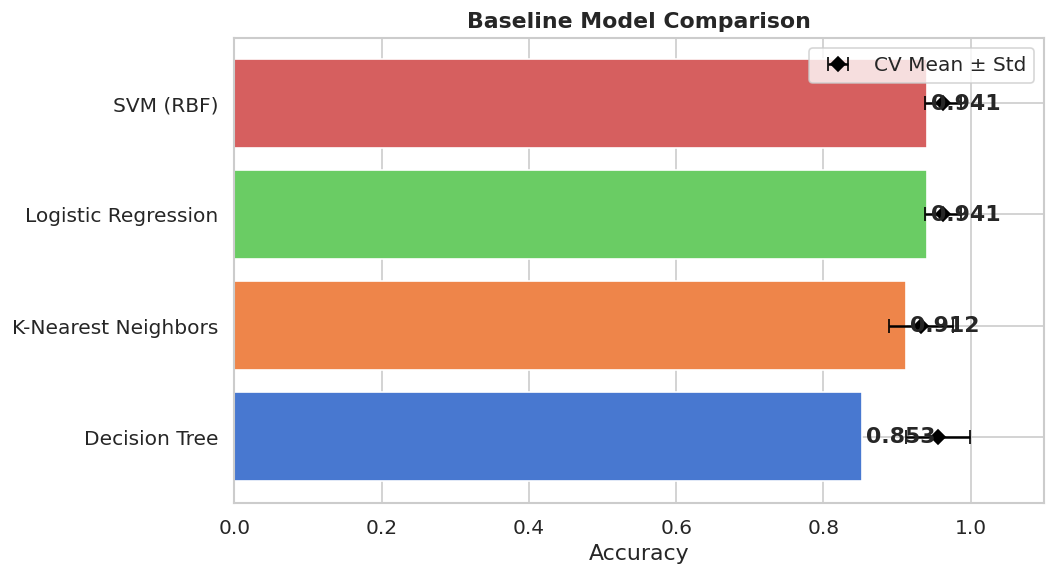

In [20]:

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

base_models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Decision Tree':       DecisionTreeClassifier(random_state=42),
    'K-Nearest Neighbors': KNeighborsClassifier(n_neighbors=5),
    'SVM (RBF)':           SVC(kernel='rbf', probability=True, random_state=42),
}

results = {}
print(f"{'Model':<25} {'CV Acc':>8} {'Std':>7} {'Test Acc':>10}")
print("-" * 55)

for name, model in base_models.items():
    cv_scores = cross_val_score(model, X_train, y_train, cv=skf, scoring='accuracy')
    model.fit(X_train, y_train)
    test_acc = accuracy_score(y_test, model.predict(X_test))
    results[name] = {'cv_mean': cv_scores.mean(), 'cv_std': cv_scores.std(), 'test_acc': test_acc}
    print(f"{name:<25} {cv_scores.mean():>8.4f} {cv_scores.std():>7.4f} {test_acc:>10.4f}")

# Bar chart
res_df = pd.DataFrame(results).T.sort_values('test_acc', ascending=True)
plt.figure(figsize=(9, 5))
bars = plt.barh(res_df.index, res_df['test_acc'], color=sns.color_palette('muted', len(res_df)))
plt.errorbar(res_df['cv_mean'], res_df.index, xerr=res_df['cv_std'],
             fmt='D', color='black', capsize=4, label='CV Mean ± Std')
for bar, val in zip(bars, res_df['test_acc']):
    plt.text(bar.get_width() + 0.005, bar.get_y() + bar.get_height()/2,
             f'{val:.3f}', va='center', fontweight='bold')
plt.xlabel('Accuracy'); plt.title('Baseline Model Comparison', fontweight='bold')
plt.xlim(0, 1.1)
plt.legend()
plt.tight_layout()
plt.savefig('baseline_models.png', bbox_inches='tight')
plt.show()


## 7. 🌲 Ensemble Learning — Random Forest & XGBoost

### 7.1 Random Forest with Hyperparameter Tuning

In [21]:

# Grid search for Random Forest
rf_param_grid = {
    'n_estimators':     [100, 200],
    'max_depth':        [None, 10, 20],
    'min_samples_split':[2, 5],
    'max_features':     ['sqrt', 'log2']
}

rf_base = RandomForestClassifier(random_state=42)
rf_grid = GridSearchCV(rf_base, rf_param_grid, cv=5, scoring='accuracy',
                        n_jobs=-1, verbose=0)
rf_grid.fit(X_train, y_train)

print(f"✅ Best RF Params : {rf_grid.best_params_}")
print(f"✅ Best CV Score  : {rf_grid.best_score_:.4f}")

best_rf = rf_grid.best_estimator_
rf_pred  = best_rf.predict(X_test)
rf_proba = best_rf.predict_proba(X_test)

print(f"\n📊 Random Forest Test Accuracy: {accuracy_score(y_test, rf_pred):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, rf_pred, target_names=le.classes_))


✅ Best RF Params : {'max_depth': None, 'max_features': 'sqrt', 'min_samples_split': 2, 'n_estimators': 100}
✅ Best CV Score  : 0.9627

📊 Random Forest Test Accuracy: 0.8824

Classification Report:
                precision    recall  f1-score   support

     Developed       1.00      0.88      0.93         8
    Developing       0.93      0.82      0.88        17
Underdeveloped       0.75      1.00      0.86         9

      accuracy                           0.88        34
     macro avg       0.89      0.90      0.89        34
  weighted avg       0.90      0.88      0.88        34



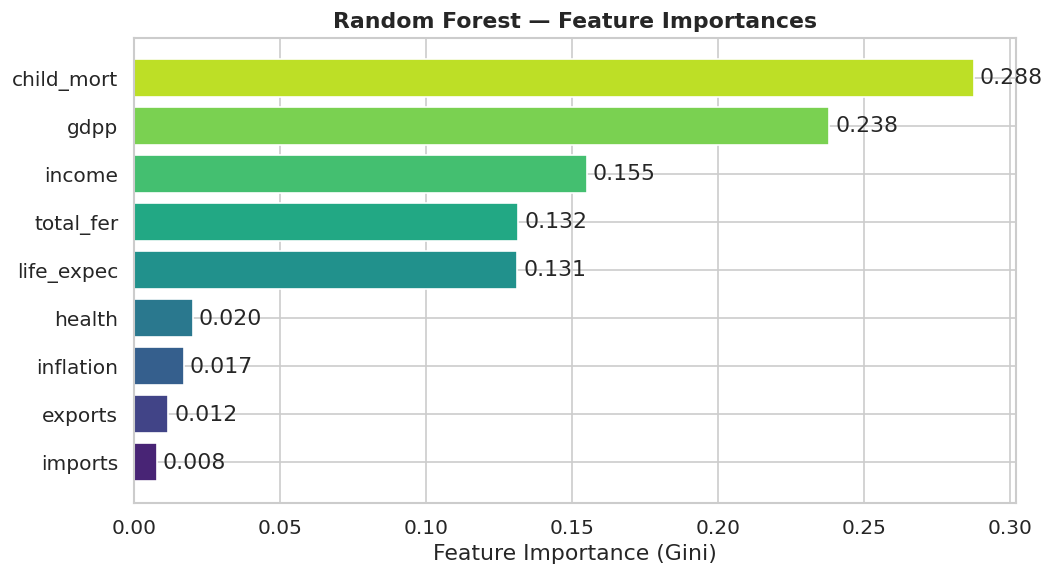

In [22]:

# Feature Importance Plot
importances = best_rf.feature_importances_
feat_df = pd.Series(importances, index=features).sort_values(ascending=True)

plt.figure(figsize=(9, 5))
colors = sns.color_palette('viridis', len(feat_df))
bars = plt.barh(feat_df.index, feat_df.values, color=colors)
for bar, val in zip(bars, feat_df.values):
    plt.text(bar.get_width() + 0.002, bar.get_y() + bar.get_height()/2,
             f'{val:.3f}', va='center')
plt.xlabel('Feature Importance (Gini)')
plt.title('Random Forest — Feature Importances', fontweight='bold')
plt.tight_layout()
plt.savefig('rf_feature_importance.png', bbox_inches='tight')
plt.show()


### 7.2 XGBoost with Hyperparameter Tuning

In [23]:

xgb_param_grid = {
    'n_estimators':  [100, 200],
    'max_depth':     [3, 5, 7],
    'learning_rate': [0.05, 0.1, 0.2],
    'subsample':     [0.8, 1.0],
}

xgb_base = XGBClassifier(use_label_encoder=False, eval_metric='mlogloss',
                           random_state=42, verbosity=0)
xgb_grid = GridSearchCV(xgb_base, xgb_param_grid, cv=5, scoring='accuracy',
                         n_jobs=-1, verbose=0)
xgb_grid.fit(X_train, y_train)

print(f"✅ Best XGB Params : {xgb_grid.best_params_}")
print(f"✅ Best CV Score   : {xgb_grid.best_score_:.4f}")

best_xgb  = xgb_grid.best_estimator_
xgb_pred  = best_xgb.predict(X_test)
xgb_proba = best_xgb.predict_proba(X_test)

print(f"\n📊 XGBoost Test Accuracy: {accuracy_score(y_test, xgb_pred):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, xgb_pred, target_names=le.classes_))


✅ Best XGB Params : {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 100, 'subsample': 0.8}
✅ Best CV Score   : 0.9701

📊 XGBoost Test Accuracy: 0.9412

Classification Report:
                precision    recall  f1-score   support

     Developed       1.00      0.88      0.93         8
    Developing       0.94      0.94      0.94        17
Underdeveloped       0.90      1.00      0.95         9

      accuracy                           0.94        34
     macro avg       0.95      0.94      0.94        34
  weighted avg       0.94      0.94      0.94        34



### 7.3 Voting Ensemble (Soft Voting)

In [24]:

voting_clf = VotingClassifier(
    estimators=[
        ('rf',  best_rf),
        ('xgb', best_xgb),
        ('svm', SVC(kernel='rbf', probability=True, random_state=42))
    ],
    voting='soft'
)
voting_clf.fit(X_train, y_train)
vote_pred  = voting_clf.predict(X_test)

print(f"📊 Voting Ensemble Test Accuracy: {accuracy_score(y_test, vote_pred):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, vote_pred, target_names=le.classes_))


📊 Voting Ensemble Test Accuracy: 0.9412

Classification Report:
                precision    recall  f1-score   support

     Developed       1.00      0.88      0.93         8
    Developing       0.94      0.94      0.94        17
Underdeveloped       0.90      1.00      0.95         9

      accuracy                           0.94        34
     macro avg       0.95      0.94      0.94        34
  weighted avg       0.94      0.94      0.94        34



### 7.4 Confusion Matrices

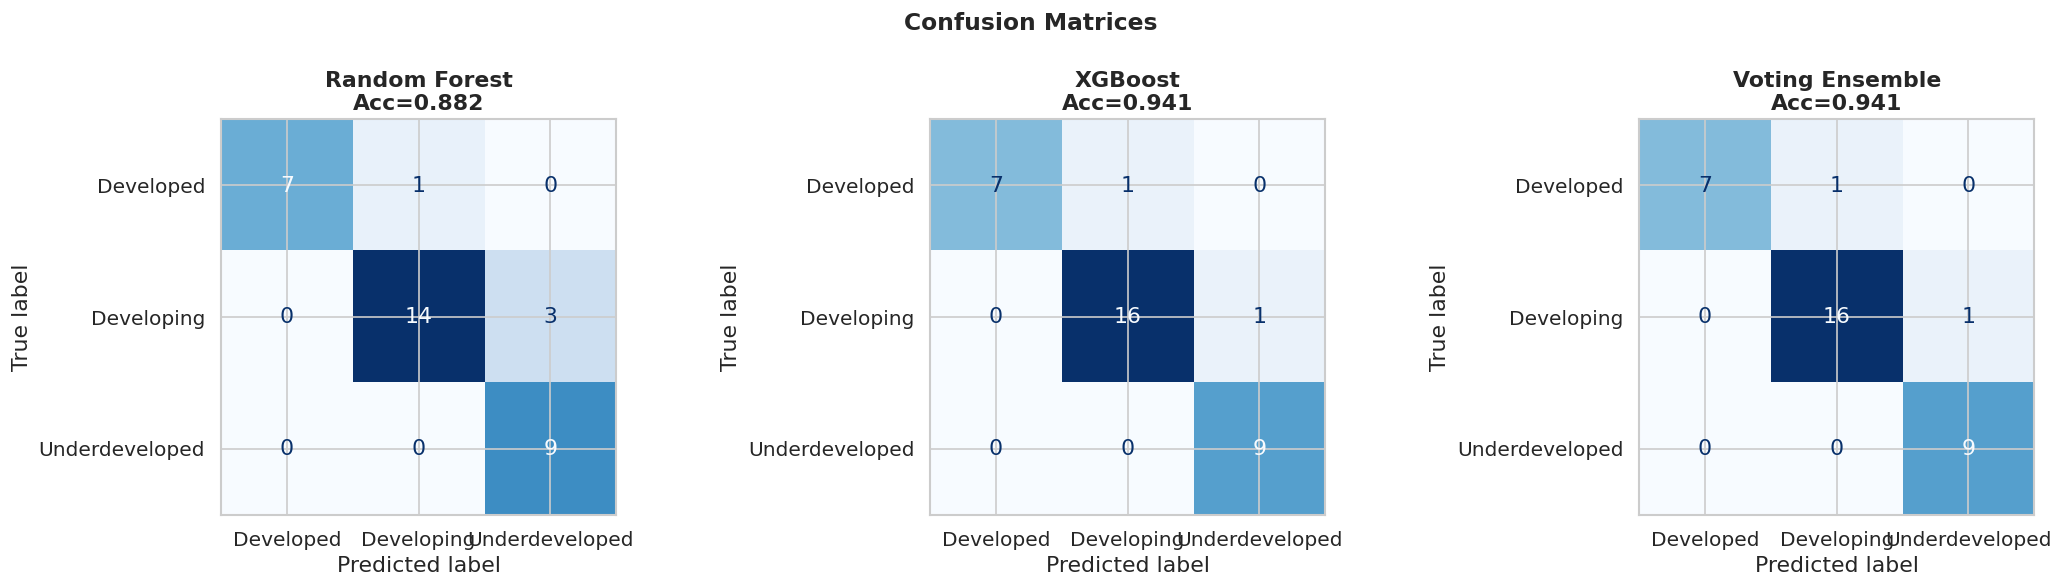

In [25]:

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
model_results = [
    ('Random Forest', rf_pred),
    ('XGBoost',       xgb_pred),
    ('Voting Ensemble', vote_pred)
]

for ax, (name, pred) in zip(axes, model_results):
    cm = confusion_matrix(y_test, pred)
    disp = ConfusionMatrixDisplay(cm, display_labels=le.classes_)
    disp.plot(ax=ax, cmap='Blues', colorbar=False)
    ax.set_title(f'{name}\nAcc={accuracy_score(y_test,pred):.3f}', fontweight='bold')

plt.suptitle('Confusion Matrices', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('confusion_matrices.png', bbox_inches='tight')
plt.show()


### 7.5 ROC-AUC Curves (One-vs-Rest)

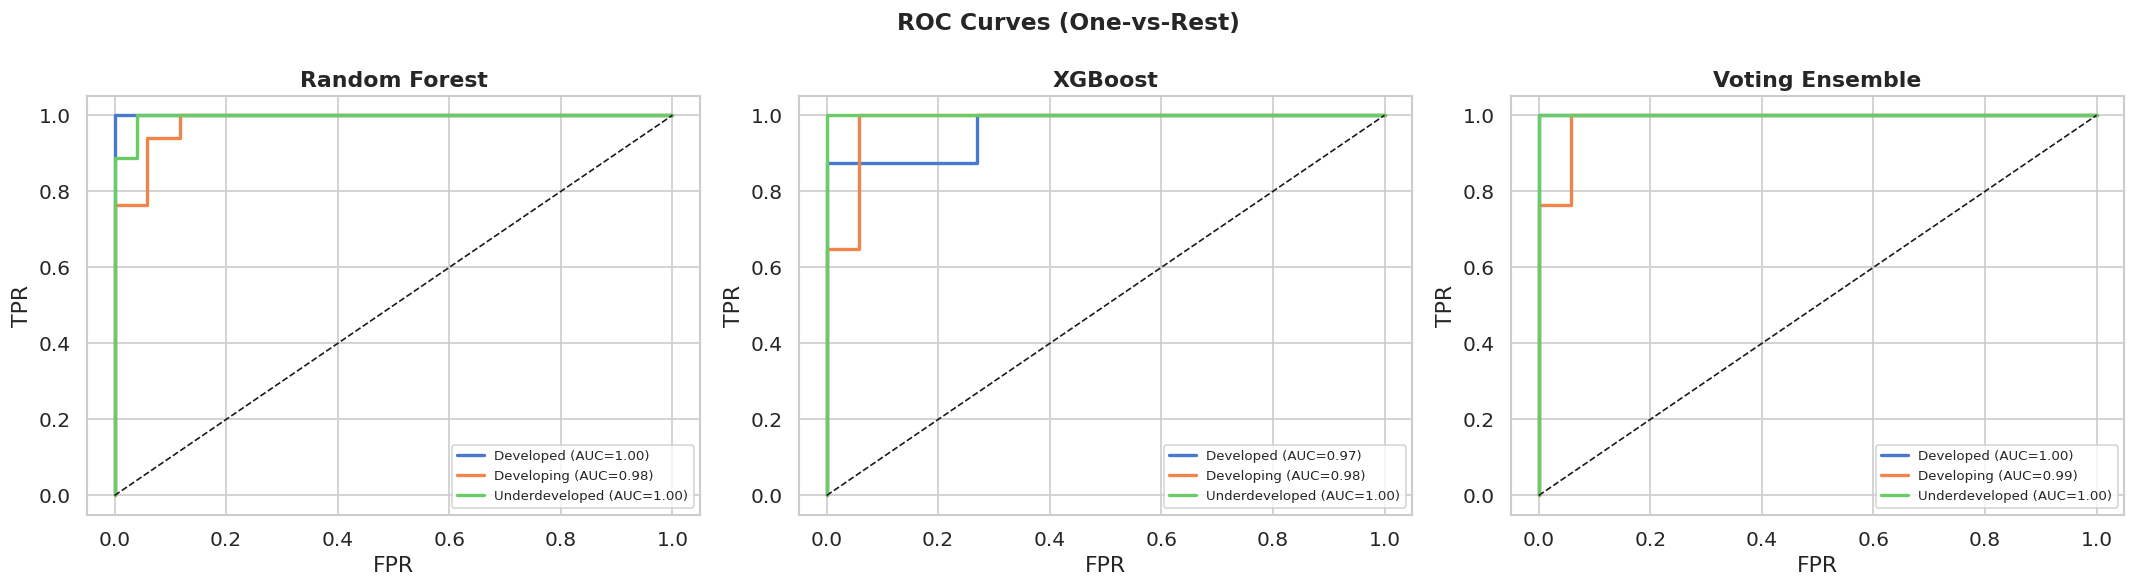

In [26]:

from sklearn.preprocessing import label_binarize
y_test_bin = label_binarize(y_test, classes=np.unique(y))

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
roc_models = [
    ('Random Forest', rf_proba),
    ('XGBoost',       xgb_proba),
    ('Voting Ensemble', voting_clf.predict_proba(X_test))
]

for ax, (name, proba) in zip(axes, roc_models):
    for i, cls in enumerate(le.classes_):
        fpr, tpr, _ = roc_curve(y_test_bin[:, i], proba[:, i])
        auc = roc_auc_score(y_test_bin[:, i], proba[:, i])
        ax.plot(fpr, tpr, linewidth=2, label=f'{cls} (AUC={auc:.2f})')
    ax.plot([0,1],[0,1],'k--', linewidth=1)
    ax.set_title(f'{name}', fontweight='bold')
    ax.set_xlabel('FPR'); ax.set_ylabel('TPR')
    ax.legend(fontsize=8)

plt.suptitle('ROC Curves (One-vs-Rest)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('roc_curves.png', bbox_inches='tight')
plt.show()


## 8. 📊 Final Model Comparison & Leaderboard

,Model,CV Accuracy,Test Accuracy,ROC-AUC
1,Logistic Regression,0.964000,0.941200,0.995100
2,XGBoost,0.969700,0.941200,0.981900
3,SVM,0.970100,0.941200,0.989800
4,Voting Ensemble,0.957800,0.941200,0.995400
5,KNN,0.934000,0.911800,0.993900
6,Random Forest,0.951900,0.882400,0.992800
7,Decision Tree,0.951700,0.852900,0.903500


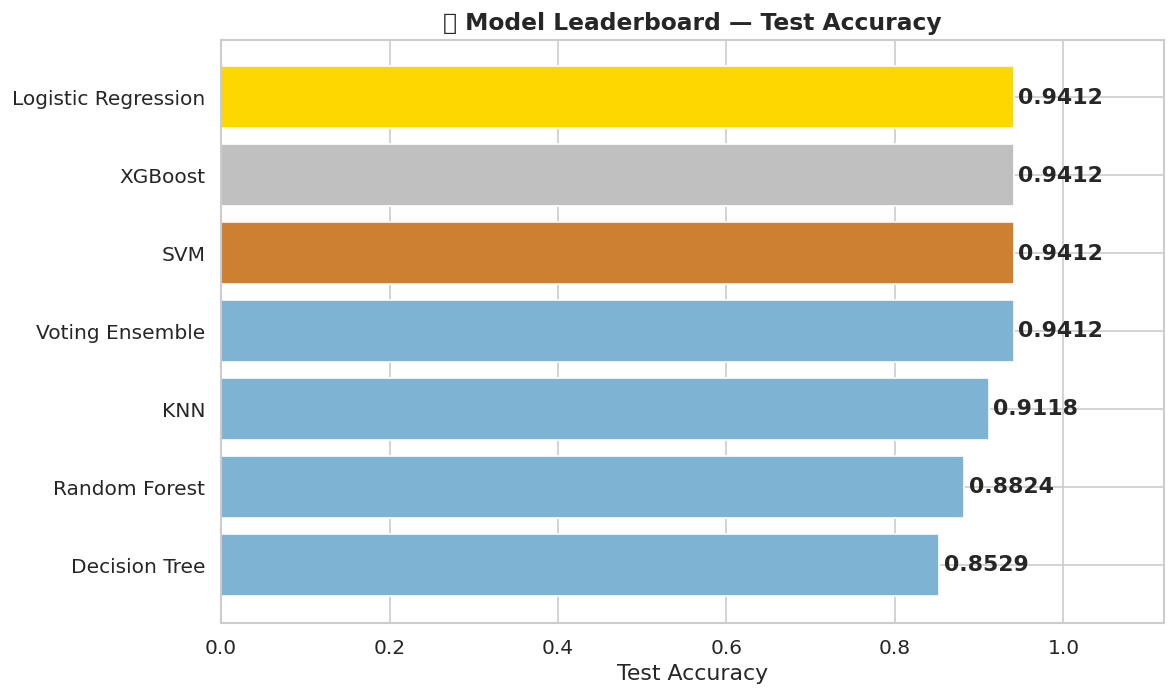

In [27]:

all_models = {
    'Logistic Regression': base_models['Logistic Regression'],
    'Decision Tree':       base_models['Decision Tree'],
    'KNN':                 base_models['K-Nearest Neighbors'],
    'SVM':                 base_models['SVM (RBF)'],
    'Random Forest':       best_rf,
    'XGBoost':             best_xgb,
    'Voting Ensemble':     voting_clf,
}

leaderboard = []
for name, model in all_models.items():
    pred = model.predict(X_test)
    proba = model.predict_proba(X_test) if hasattr(model, 'predict_proba') else None
    acc = accuracy_score(y_test, pred)
    cv  = cross_val_score(model, X_clf, y, cv=5, scoring='accuracy').mean()
    auc = roc_auc_score(label_binarize(y_test, classes=np.unique(y)),
                         proba, multi_class='ovr') if proba is not None else np.nan
    leaderboard.append({'Model': name, 'CV Accuracy': round(cv,4),
                        'Test Accuracy': round(acc,4), 'ROC-AUC': round(auc,4) if not np.isnan(auc) else '—'})

lb_df = pd.DataFrame(leaderboard).sort_values('Test Accuracy', ascending=False)
lb_df = lb_df.reset_index(drop=True)
lb_df.index += 1

display(lb_df.style.highlight_max(subset=['CV Accuracy','Test Accuracy'], color='#d4efdf'))

# Visual leaderboard
plt.figure(figsize=(10, 6))
palette_lb = ['gold' if i == 0 else 'silver' if i == 1 else '#cd7f32' if i == 2 else '#7fb3d3'
              for i in range(len(lb_df))]
bars = plt.barh(lb_df['Model'], lb_df['Test Accuracy'], color=palette_lb)
for bar, val in zip(bars, lb_df['Test Accuracy']):
    plt.text(bar.get_width() + 0.005, bar.get_y() + bar.get_height()/2,
             f'{val:.4f}', va='center', fontweight='bold')
plt.xlabel('Test Accuracy')
plt.title('🏆 Model Leaderboard — Test Accuracy', fontsize=14, fontweight='bold')
plt.xlim(0, 1.12)
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('leaderboard.png', bbox_inches='tight')
plt.show()


## 9. 💡 Actionable Business Insights

In [28]:

print("=" * 70)
print("   CUSTOMER INTELLIGENCE SYSTEM — KEY INSIGHTS")
print("=" * 70)

for c in range(OPTIMAL_K):
    sub = df[df['KMeans_Cluster'] == c]
    cat = sub['Development_Category'].mode()[0]
    print(f"\n📌 Cluster {c} — {cat} ({len(sub)} countries)")
    print(f"   Avg Child Mortality : {sub['child_mort'].mean():.1f} per 1000 births")
    print(f"   Avg Income          : ${sub['income'].mean():,.0f}")
    print(f"   Avg GDP per capita  : ${sub['gdpp'].mean():,.0f}")
    print(f"   Avg Life Expectancy : {sub['life_expec'].mean():.1f} years")
    print(f"   Avg Total Fertility : {sub['total_fer'].mean():.2f}")
    print(f"   Sample countries    : {', '.join(sub.nsmallest(5,'gdpp')['country'].tolist())}")

print("\n" + "=" * 70)
print("🏆 BEST PERFORMING MODEL")
print(f"   {lb_df.iloc[0]['Model']}  —  Test Accuracy: {lb_df.iloc[0]['Test Accuracy']}")
print("=" * 70)

print("\n📋 RECOMMENDATIONS:")
print("  1️⃣  Underdeveloped countries need urgent aid (high child mortality, low GDP).")
print("  2️⃣  Focus aid on clusters with child_mort > 50 and income < $3,000.")
print("  3️⃣  Ensemble models outperform single classifiers — use XGBoost / RF in production.")
print("  4️⃣  DBSCAN identifies anomalous countries that don't fit standard categories.")
print("  5️⃣  child_mort, gdpp, income, and life_expec are the most predictive features.")


   CUSTOMER INTELLIGENCE SYSTEM — KEY INSIGHTS

📌 Cluster 0 — Developed (37 countries)
   Avg Child Mortality : 5.2 per 1000 births
   Avg Income          : $45,057
   Avg GDP per capita  : $42,103
   Avg Life Expectancy : 80.0 years
   Avg Total Fertility : 1.76
   Sample countries    : Slovak Republic, Czech Republic, Bahrain, Malta, South Korea

📌 Cluster 1 — Developing (84 countries)
   Avg Child Mortality : 22.4 per 1000 births
   Avg Income          : $12,191
   Avg GDP per capita  : $6,229
   Avg Life Expectancy : 72.6 years
   Avg Total Fertility : 2.32
   Sample countries    : Nepal, Tajikistan, Bangladesh, Cambodia, Kyrgyz Republic

📌 Cluster 2 — Underdeveloped (46 countries)
   Avg Child Mortality : 93.8 per 1000 births
   Avg Income          : $3,739
   Avg GDP per capita  : $1,826
   Avg Life Expectancy : 59.2 years
   Avg Total Fertility : 5.05
   Sample countries    : Burundi, Liberia, Congo, Dem. Rep., Niger, Sierra Leone

🏆 BEST PERFORMING MODEL
   Logistic Regression 

## 10. 💾 Save Results

In [29]:

output_cols = ['country'] + features + ['KMeans_Cluster', 'DBSCAN_Cluster', 'Development_Category']
output_df = df[output_cols].copy()
output_df.to_csv('country_intelligence_results.csv', index=False)
print("✅ Results saved to 'country_intelligence_results.csv'")
print(f"   Shape: {output_df.shape}")
display(output_df.head(10))


✅ Results saved to 'country_intelligence_results.csv'
   Shape: (167, 13)


,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp,KMeans_Cluster,DBSCAN_Cluster,Development_Category
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.440,56.2,5.82,553,2,0,Underdeveloped
1,Albania,16.6,28.0,6.55,48.6,9930,4.490,76.3,1.65,4090,1,0,Developing
2,Algeria,27.3,38.4,4.17,31.4,12900,16.100,76.5,2.89,4460,1,0,Developing
3,Angola,119.0,62.3,2.85,42.9,5900,22.400,60.1,6.16,3530,2,0,Underdeveloped
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.440,76.8,2.13,12200,1,0,Developing
5,Argentina,14.5,18.9,8.10,16.0,18700,20.900,75.8,2.37,10300,1,0,Developing
6,Armenia,18.1,20.8,4.40,45.3,6700,7.770,73.3,1.69,3220,1,0,Developing
7,Australia,4.8,19.8,8.73,20.9,41400,1.160,82.0,1.93,51900,0,0,Developed
8,Austria,4.3,51.3,11.00,47.8,43200,0.873,80.5,1.44,46900,0,0,Developed
9,Azerbaijan,39.2,54.3,5.88,20.7,16000,13.800,69.1,1.92,5840,1,0,Developing


---
## ✅ Pipeline Complete!

| Stage | Details |
|---|---|
| **EDA** | Distributions, correlations, outlier detection, country rankings |
| **Preprocessing** | Winsorization, StandardScaler, PCA (2D & 3D) |
| **K-Means** | Elbow + Silhouette + DB index → K=3 optimal |
| **DBSCAN** | Density-based clustering with noise detection |
| **Hierarchical** | Ward linkage dendrogram |
| **Classification** | LR, DT, KNN, SVM baseline models |
| **Ensemble** | Random Forest (GridSearchCV), XGBoost (GridSearchCV), Voting |
| **Evaluation** | Confusion matrices, ROC-AUC, CV scores, leaderboard |
